NAME: ALOK KUMAR MAVI

SECTION: B

ROLL.NO.: 05

CU ID: CU240251681

# LAB SHEET - 09

### Data Storytelling and Business Insight Generation using Interactive Visualizations

## Aim

To create a compelling data-driven story by analyzing a real-world dataset,
developing meaningful visualizations, and presenting actionable business
insights to support strategic decision-making.

## Dataset

Netflix Movies and TV Shows Dataset

In [ ]:
%pip install -q pandas numpy matplotlib seaborn plotly kaleido==0.2.1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 MB 4.7 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

from plotly.subplots import make_subplots
from IPython.display import display, HTML

pd.set_option("display.max_columns", None)

sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


In [ ]:
from IPython.display import display, Image
import plotly.io as pio

pio.renderers.default = "colab"

print("Libraries imported successfully.")

Libraries imported successfully.


## Step 1: Select a Real-World Dataset

The Netflix Movies and TV Shows Dataset is selected for the experiment.

The dataset contains information such as title, content type, country,
release year, rating, duration, genres, and date added.

In [ ]:
from google.colab import files
import io
import os

uploaded = files.upload()

print("Uploaded files:")
for filename in uploaded.keys():
    print(filename)

Saving netflix_titles.csv to netflix_titles.csv
Uploaded files:
netflix_titles.csv


In [ ]:
# Find the uploaded CSV file
csv_files = [filename for filename in uploaded.keys() if filename.lower().endswith(".csv")]

if not csv_files:
    raise FileNotFoundError("No CSV file was uploaded.")

file_name = csv_files[0]

# Load dataset
df = pd.read_csv(io.BytesIO(uploaded[file_name]))

print("Dataset loaded successfully.")
print("File:", file_name)
print("Shape:", df.shape)

df.head()

Dataset loaded successfully.
File: netflix_titles.csv
Shape: (8807, 12)


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


## Step 2: Analytical Objective

### Business Objective

The objective of this analysis is to understand the composition and growth
of Netflix's content library.

The analysis focuses on:

- The distribution of Movies and TV Shows.
- Content growth over time.
- Popular content ratings.
- Major content-producing countries.
- Content duration patterns.
- Relationships between important numerical variables.

The findings will be used to generate actionable business insights that can
support content planning and strategic decision-making.

In [ ]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 8807
Number of columns: 12


In [ ]:
print("Column names:")
print(df.columns.tolist())

Column names:
['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [ ]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
show_id,8807,8807,s8807,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
type,8807,2,Movie,6131,NaN,NaN,NaN,NaN,NaN,NaN,NaN
title,8807,8807,Zubaan,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
director,6173,4528,Rajiv Chilaka,19,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cast,7982,7692,David Attenborough,19,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country,7976,748,United States,2818,NaN,NaN,NaN,NaN,NaN,NaN,NaN
date_added,8797,1767,"January 1, 2020",109,NaN,NaN,NaN,NaN,NaN,NaN,NaN
release_year,8807.0,NaN,NaN,NaN,2014.180198,8.819312,1925.0,2013.0,2017.0,2019.0,2021.0
rating,8803,17,TV-MA,3207,NaN,NaN,NaN,NaN,NaN,NaN,NaN
duration,8804,220,1 Season,1793,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
missing_summary = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing Percentage": (df.isnull().mean() * 100).round(2)
})

missing_summary.sort_values(
    by="Missing Values",
    ascending=False
)

,Missing Values,Missing Percentage
director,2634,29.91
country,831,9.44
cast,825,9.37
date_added,10,0.11
rating,4,0.05
duration,3,0.03
show_id,0,0.00
type,0,0.00
title,0,0.00
release_year,0,0.00


In [ ]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [ ]:
df.nunique().sort_values(ascending=False)

,0
show_id,8807
title,8807
description,8775
cast,7692
director,4528
date_added,1767
country,748
listed_in,514
duration,220
release_year,74


In [ ]:
# Make a copy for analysis
eda_df = df.copy()

# Convert release year to numeric
eda_df["release_year"] = pd.to_numeric(
    eda_df["release_year"],
    errors="coerce"
)

# Convert date_added to datetime
eda_df["date_added"] = pd.to_datetime(
    eda_df["date_added"],
    errors="coerce"
)

# Extract year content was added to Netflix
eda_df["date_added_year"] = eda_df["date_added"].dt.year

# Extract first country
eda_df["primary_country"] = (
    eda_df["country"]
    .fillna("Unknown")
    .str.split(",")
    .str[0]
    .str.strip()
)

# Extract first genre/category
eda_df["primary_genre"] = (
    eda_df["listed_in"]
    .fillna("Unknown")
    .str.split(",")
    .str[0]
    .str.strip()
)

# Number of listed genres
eda_df["num_genres"] = (
    eda_df["listed_in"]
    .fillna("")
    .apply(lambda x: len([g for g in x.split(",") if g.strip()]))
)

# Number of countries associated with each title
eda_df["num_countries"] = (
    eda_df["country"]
    .fillna("")
    .apply(lambda x: len([c for c in x.split(",") if c.strip()]))
)

# Extract movie duration in minutes
eda_df["duration_minutes"] = np.where(
    eda_df["type"].eq("Movie"),
    pd.to_numeric(
        eda_df["duration"].str.extract(r"(\d+)")[0],
        errors="coerce"
    ),
    np.nan
)

# Extract TV show duration in seasons
eda_df["duration_seasons"] = np.where(
    eda_df["type"].eq("TV Show"),
    pd.to_numeric(
        eda_df["duration"].str.extract(r"(\d+)")[0],
        errors="coerce"
    ),
    np.nan
)

eda_df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,date_added_year,primary_country,primary_genre,num_genres,num_countries,duration_minutes,duration_seasons
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021.0,United States,Documentaries,1,1,90.0,NaN
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021.0,South Africa,International TV Shows,3,1,NaN,2.0
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021.0,Unknown,Crime TV Shows,3,0,NaN,1.0
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021.0,Unknown,Docuseries,2,0,NaN,1.0
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021.0,India,International TV Shows,3,1,NaN,2.0


In [ ]:
type_counts = eda_df["type"].value_counts()

print(type_counts)

type
Movie      6131
TV Show    2676
Name: count, dtype: int64


In [ ]:
rating_counts = eda_df["rating"].value_counts()

print(rating_counts.head(10))

rating
TV-MA    3207
TV-14    2160
TV-PG     863
R         799
PG-13     490
TV-Y7     334
TV-Y      307
PG        287
TV-G      220
NR         80
Name: count, dtype: int64


In [ ]:
country_counts = eda_df["primary_country"].value_counts()

print(country_counts.head(10))

primary_country
United States     3211
India             1008
Unknown            831
United Kingdom     628
Canada             271
Japan              259
France             212
South Korea        211
Spain              181
Mexico             134
Name: count, dtype: int64


In [ ]:
genre_counts = eda_df["primary_genre"].value_counts()

print(genre_counts.head(10))

primary_genre
Dramas                      1600
Comedies                    1210
Action & Adventure           859
Documentaries                829
International TV Shows       774
Children & Family Movies     605
Crime TV Shows               399
Kids' TV                     388
Stand-Up Comedy              334
Horror Movies                275
Name: count, dtype: int64


In [ ]:
total_titles = len(eda_df)

total_movies = (eda_df["type"] == "Movie").sum()

total_tv_shows = (eda_df["type"] == "TV Show").sum()

avg_release_year = eda_df["release_year"].mean()

print("KEY PERFORMANCE INDICATORS")
print("-" * 35)
print(f"Total Titles      : {total_titles:,}")
print(f"Total Movies      : {total_movies:,}")
print(f"Total TV Shows    : {total_tv_shows:,}")
print(f"Average Release Year: {avg_release_year:.0f}")

KEY PERFORMANCE INDICATORS
-----------------------------------
Total Titles      : 8,807
Total Movies      : 6,131
Total TV Shows    : 2,676
Average Release Year: 2014


In [ ]:
kpi_html = f"""
<div style="display:flex; gap:15px; flex-wrap:wrap;">

<div style="padding:20px; border:1px solid #ccc; border-radius:10px; min-width:180px; text-align:center;">
<h3>Total Titles</h3>
<h2>{total_titles:,}</h2>
</div>

<div style="padding:20px; border:1px solid #ccc; border-radius:10px; min-width:180px; text-align:center;">
<h3>Movies</h3>
<h2>{total_movies:,}</h2>
</div>

<div style="padding:20px; border:1px solid #ccc; border-radius:10px; min-width:180px; text-align:center;">
<h3>TV Shows</h3>
<h2>{total_tv_shows:,}</h2>
</div>

<div style="padding:20px; border:1px solid #ccc; border-radius:10px; min-width:180px; text-align:center;">
<h3>Avg. Release Year</h3>
<h2>{avg_release_year:.0f}</h2>
</div>

</div>
"""

display(HTML(kpi_html))

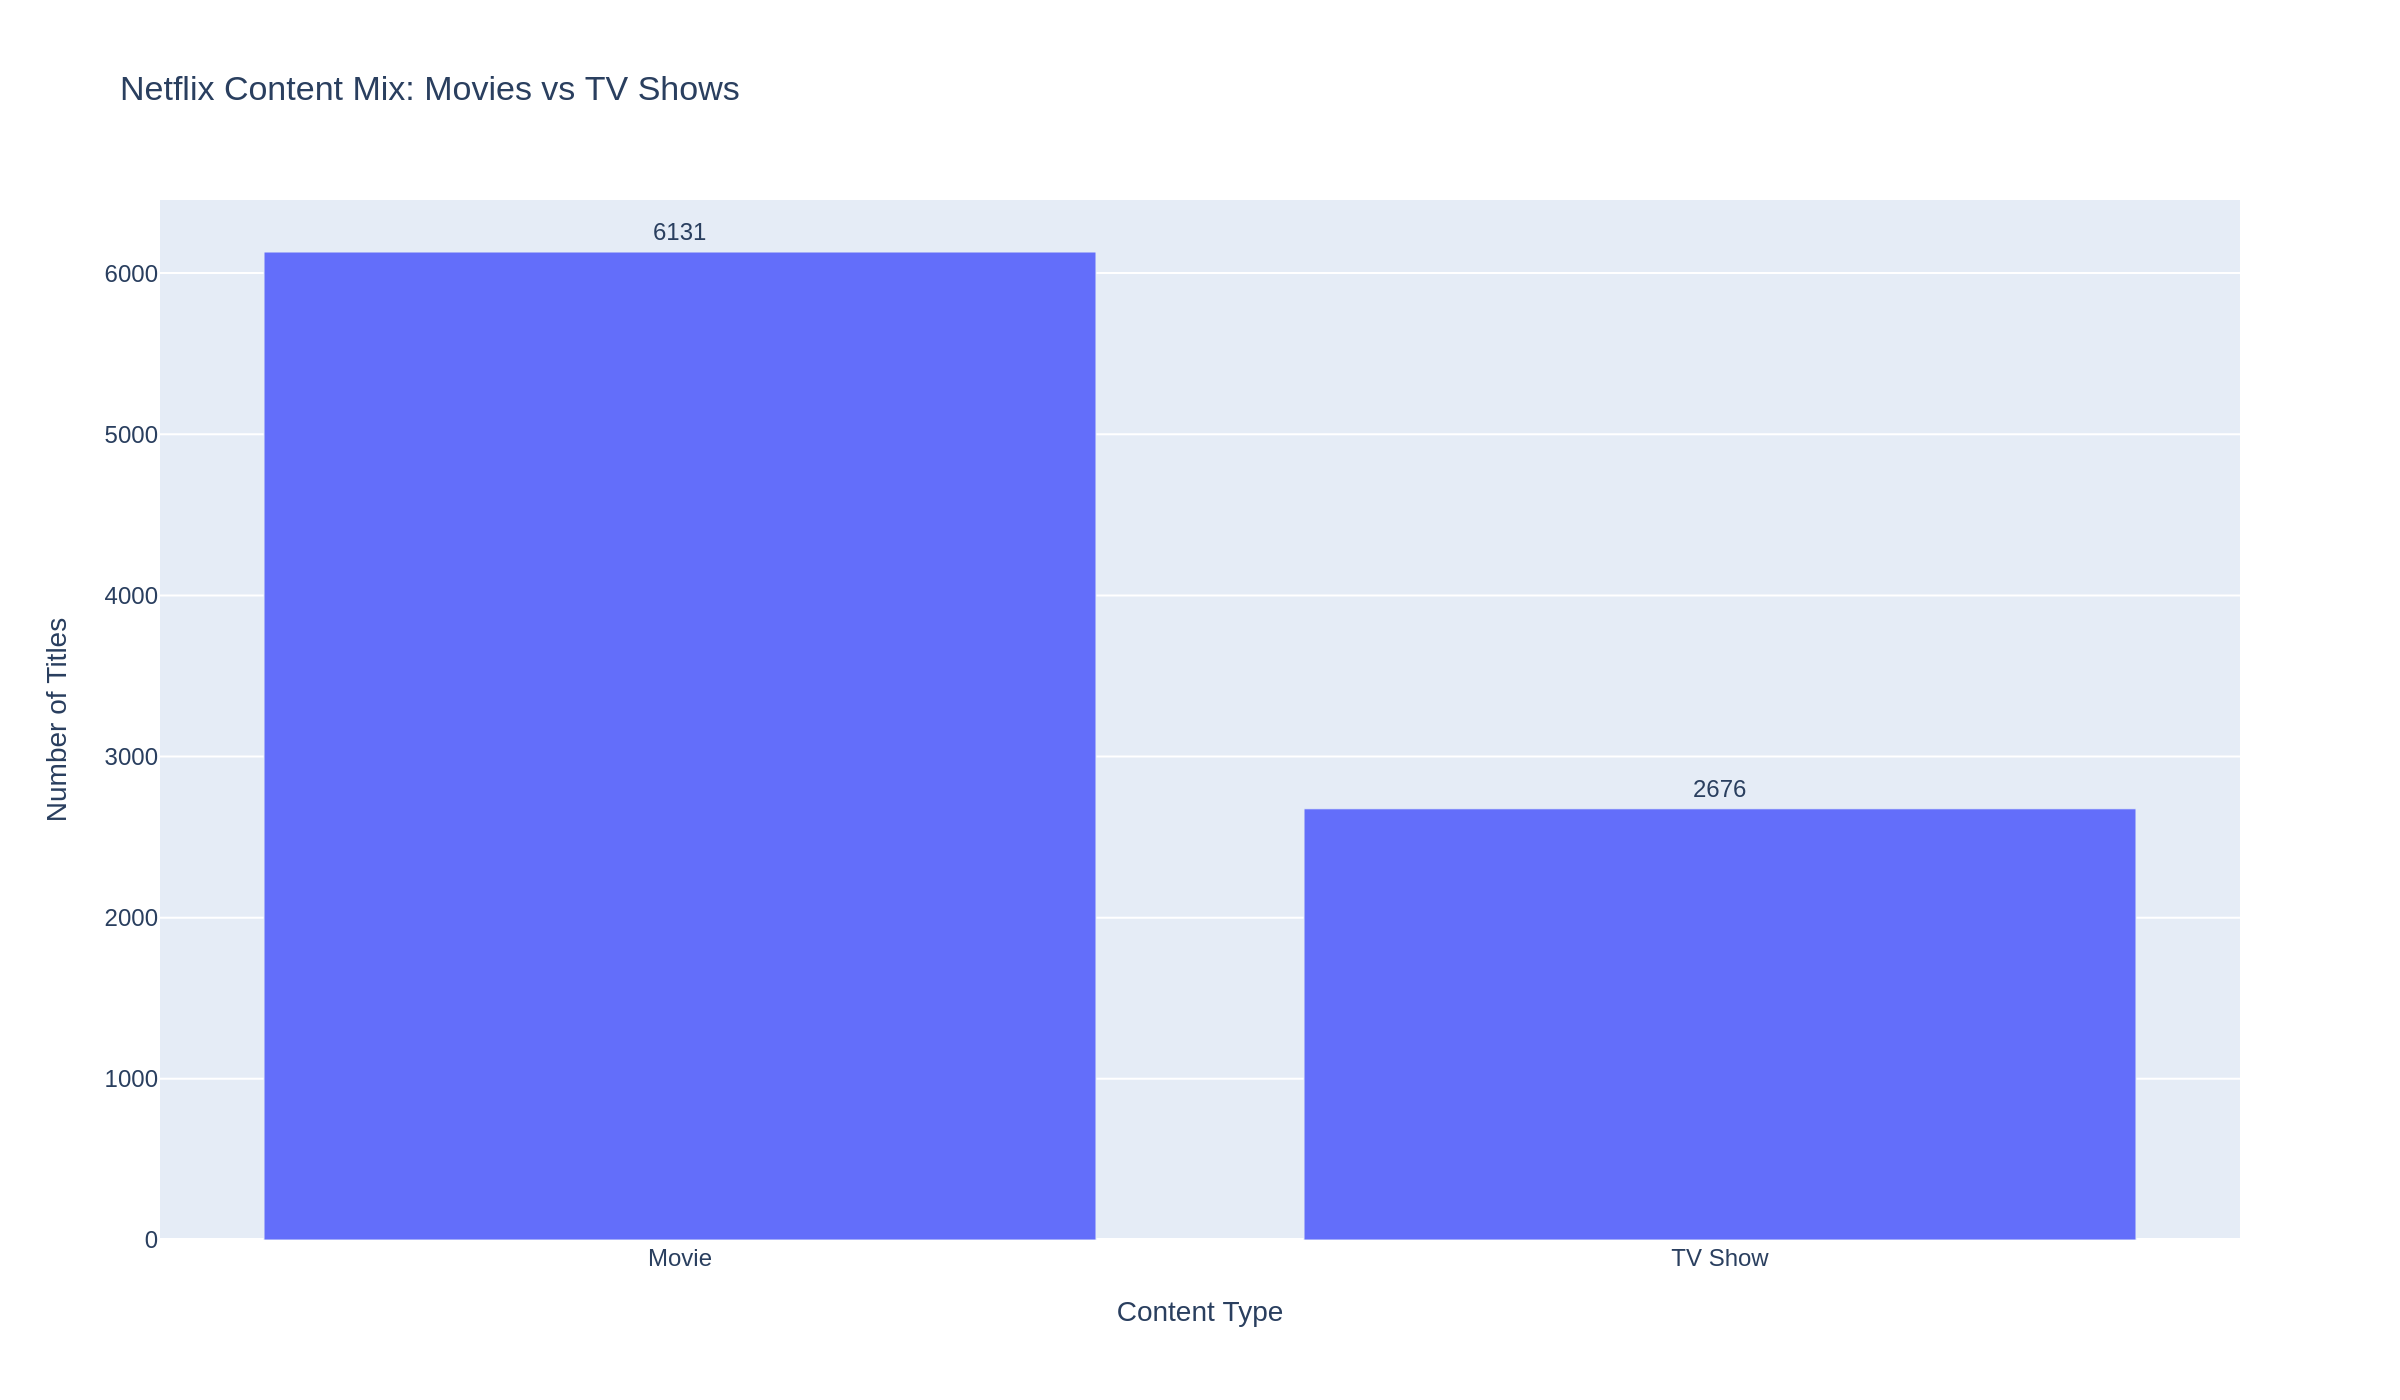

In [ ]:
fig = px.bar(
    type_counts.reset_index(),
    x="type",
    y="count",
    title="Netflix Content Mix: Movies vs TV Shows",
    labels={
        "type": "Content Type",
        "count": "Number of Titles"
    },
    text="count"
)

fig.update_traces(textposition="outside")

fig.show()
display(Image(fig.to_image(format="png", width=1200, height=700, scale=2)))

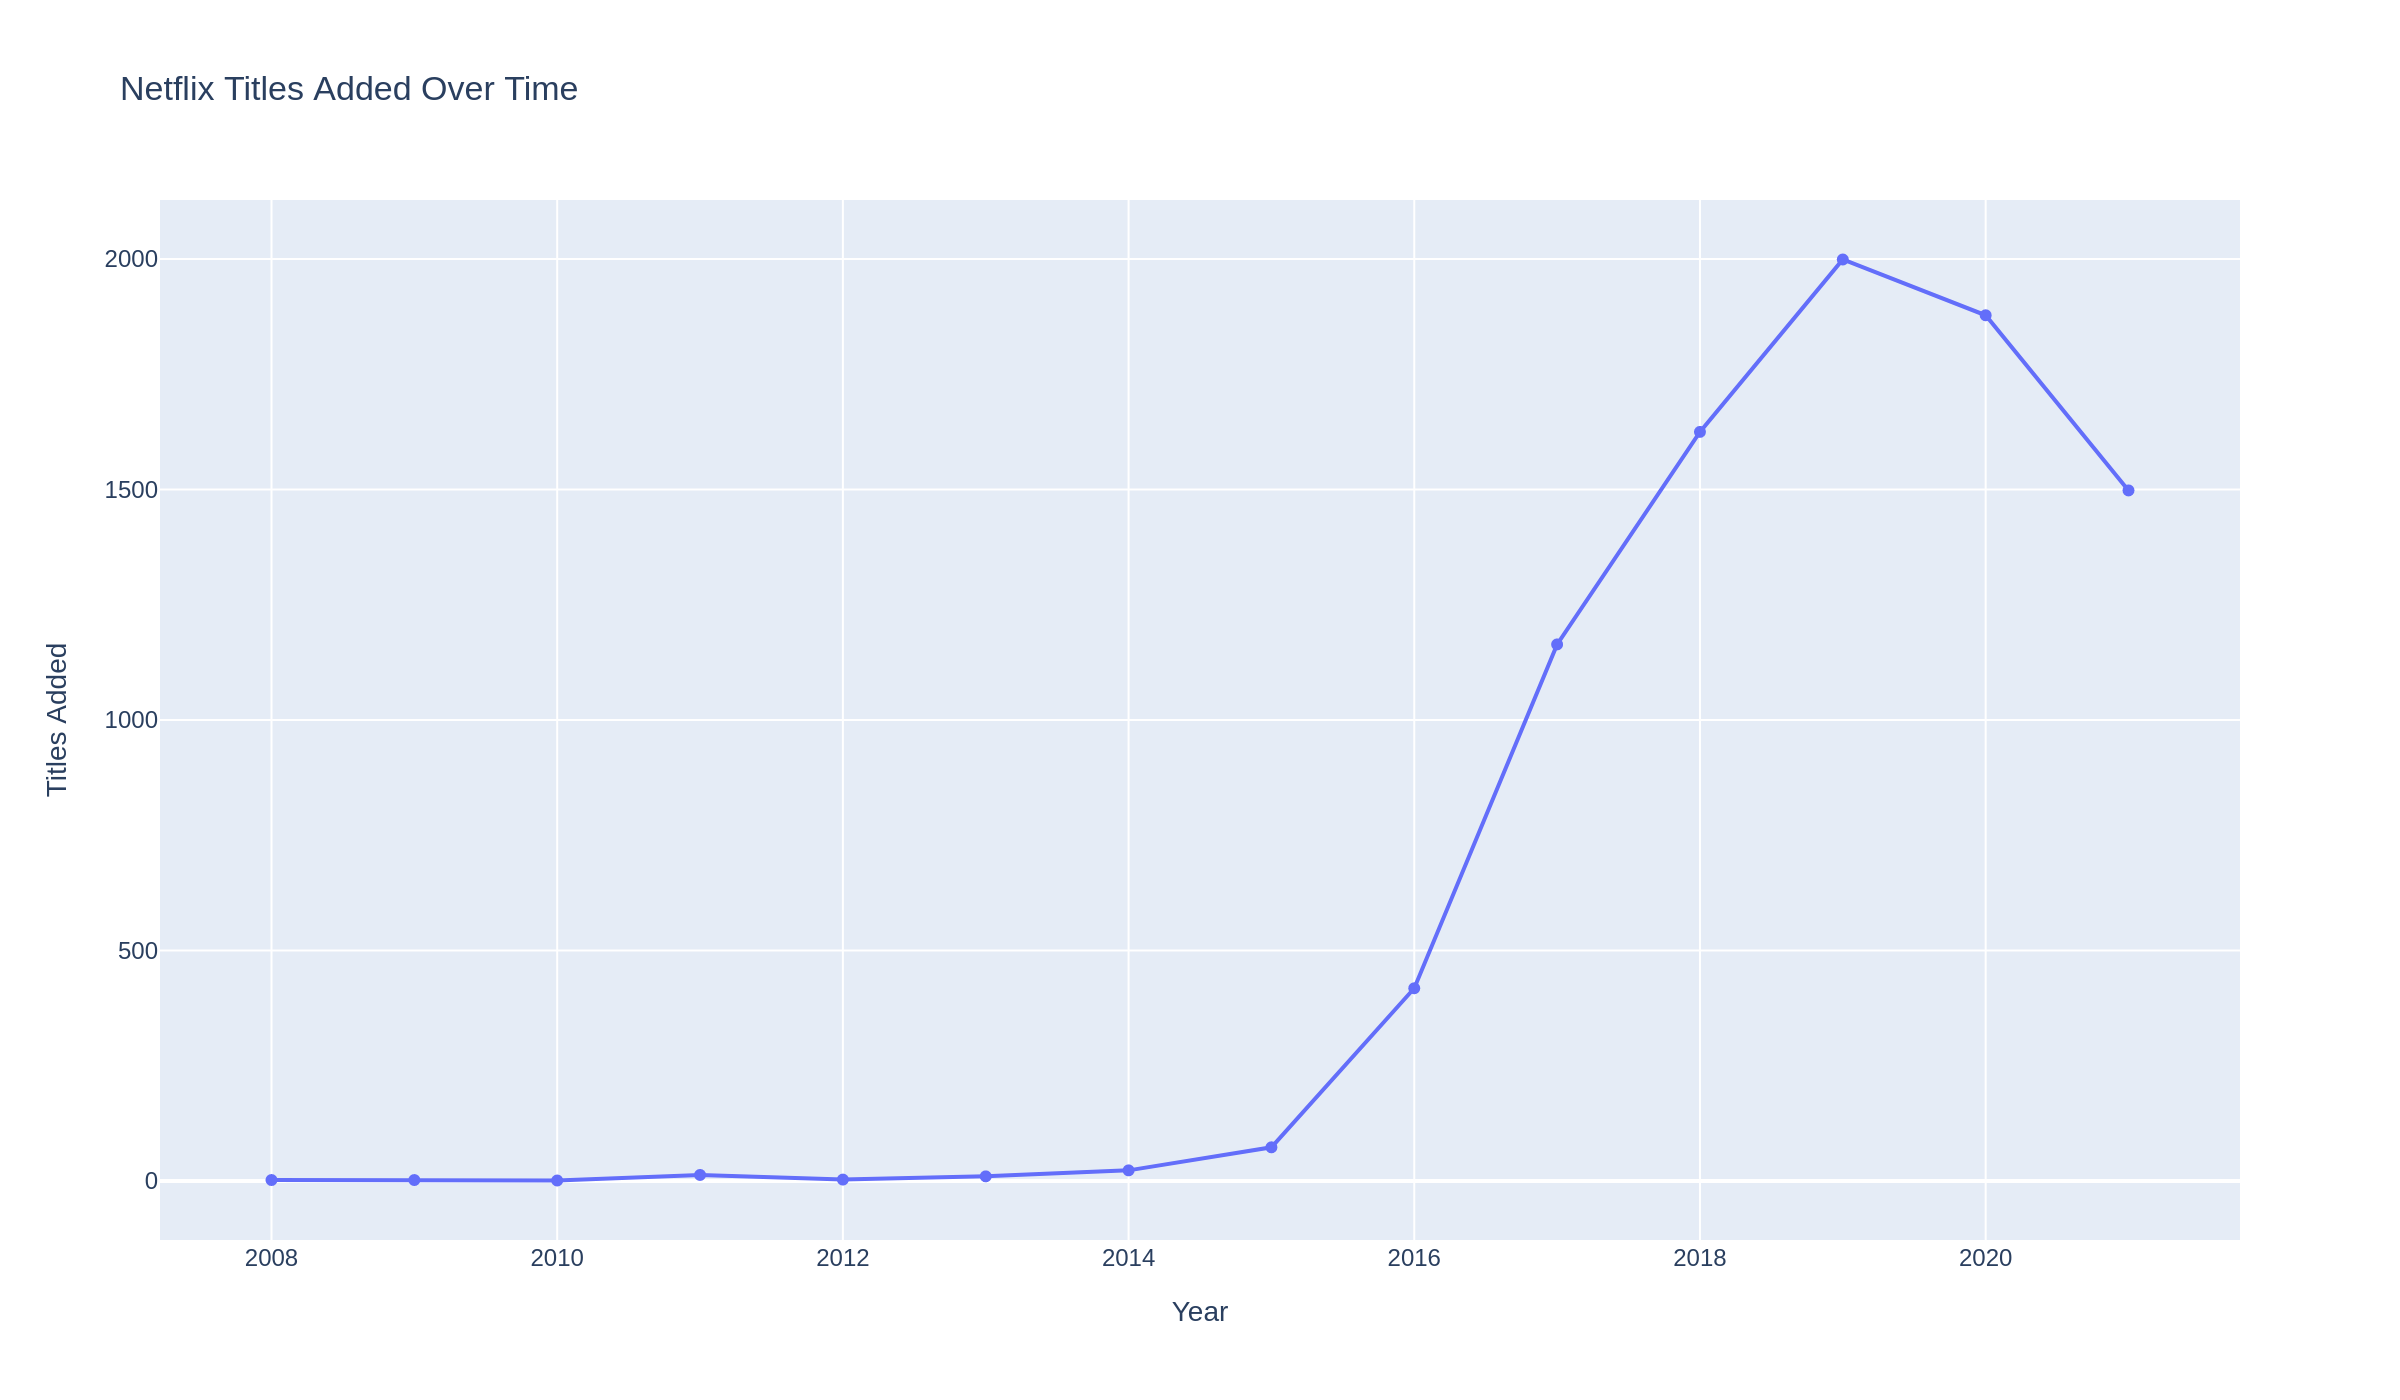

In [ ]:
yearly_additions = (
    eda_df["date_added_year"]
    .dropna()
    .astype(int)
    .value_counts()
    .sort_index()
    .reset_index()
)

yearly_additions.columns = ["year", "titles_added"]

fig = px.line(
    yearly_additions,
    x="year",
    y="titles_added",
    markers=True,
    title="Netflix Titles Added Over Time",
    labels={
        "year": "Year",
        "titles_added": "Titles Added"
    }
)

fig.show()
display(Image(fig.to_image(format="png", width=1200, height=700, scale=2)))

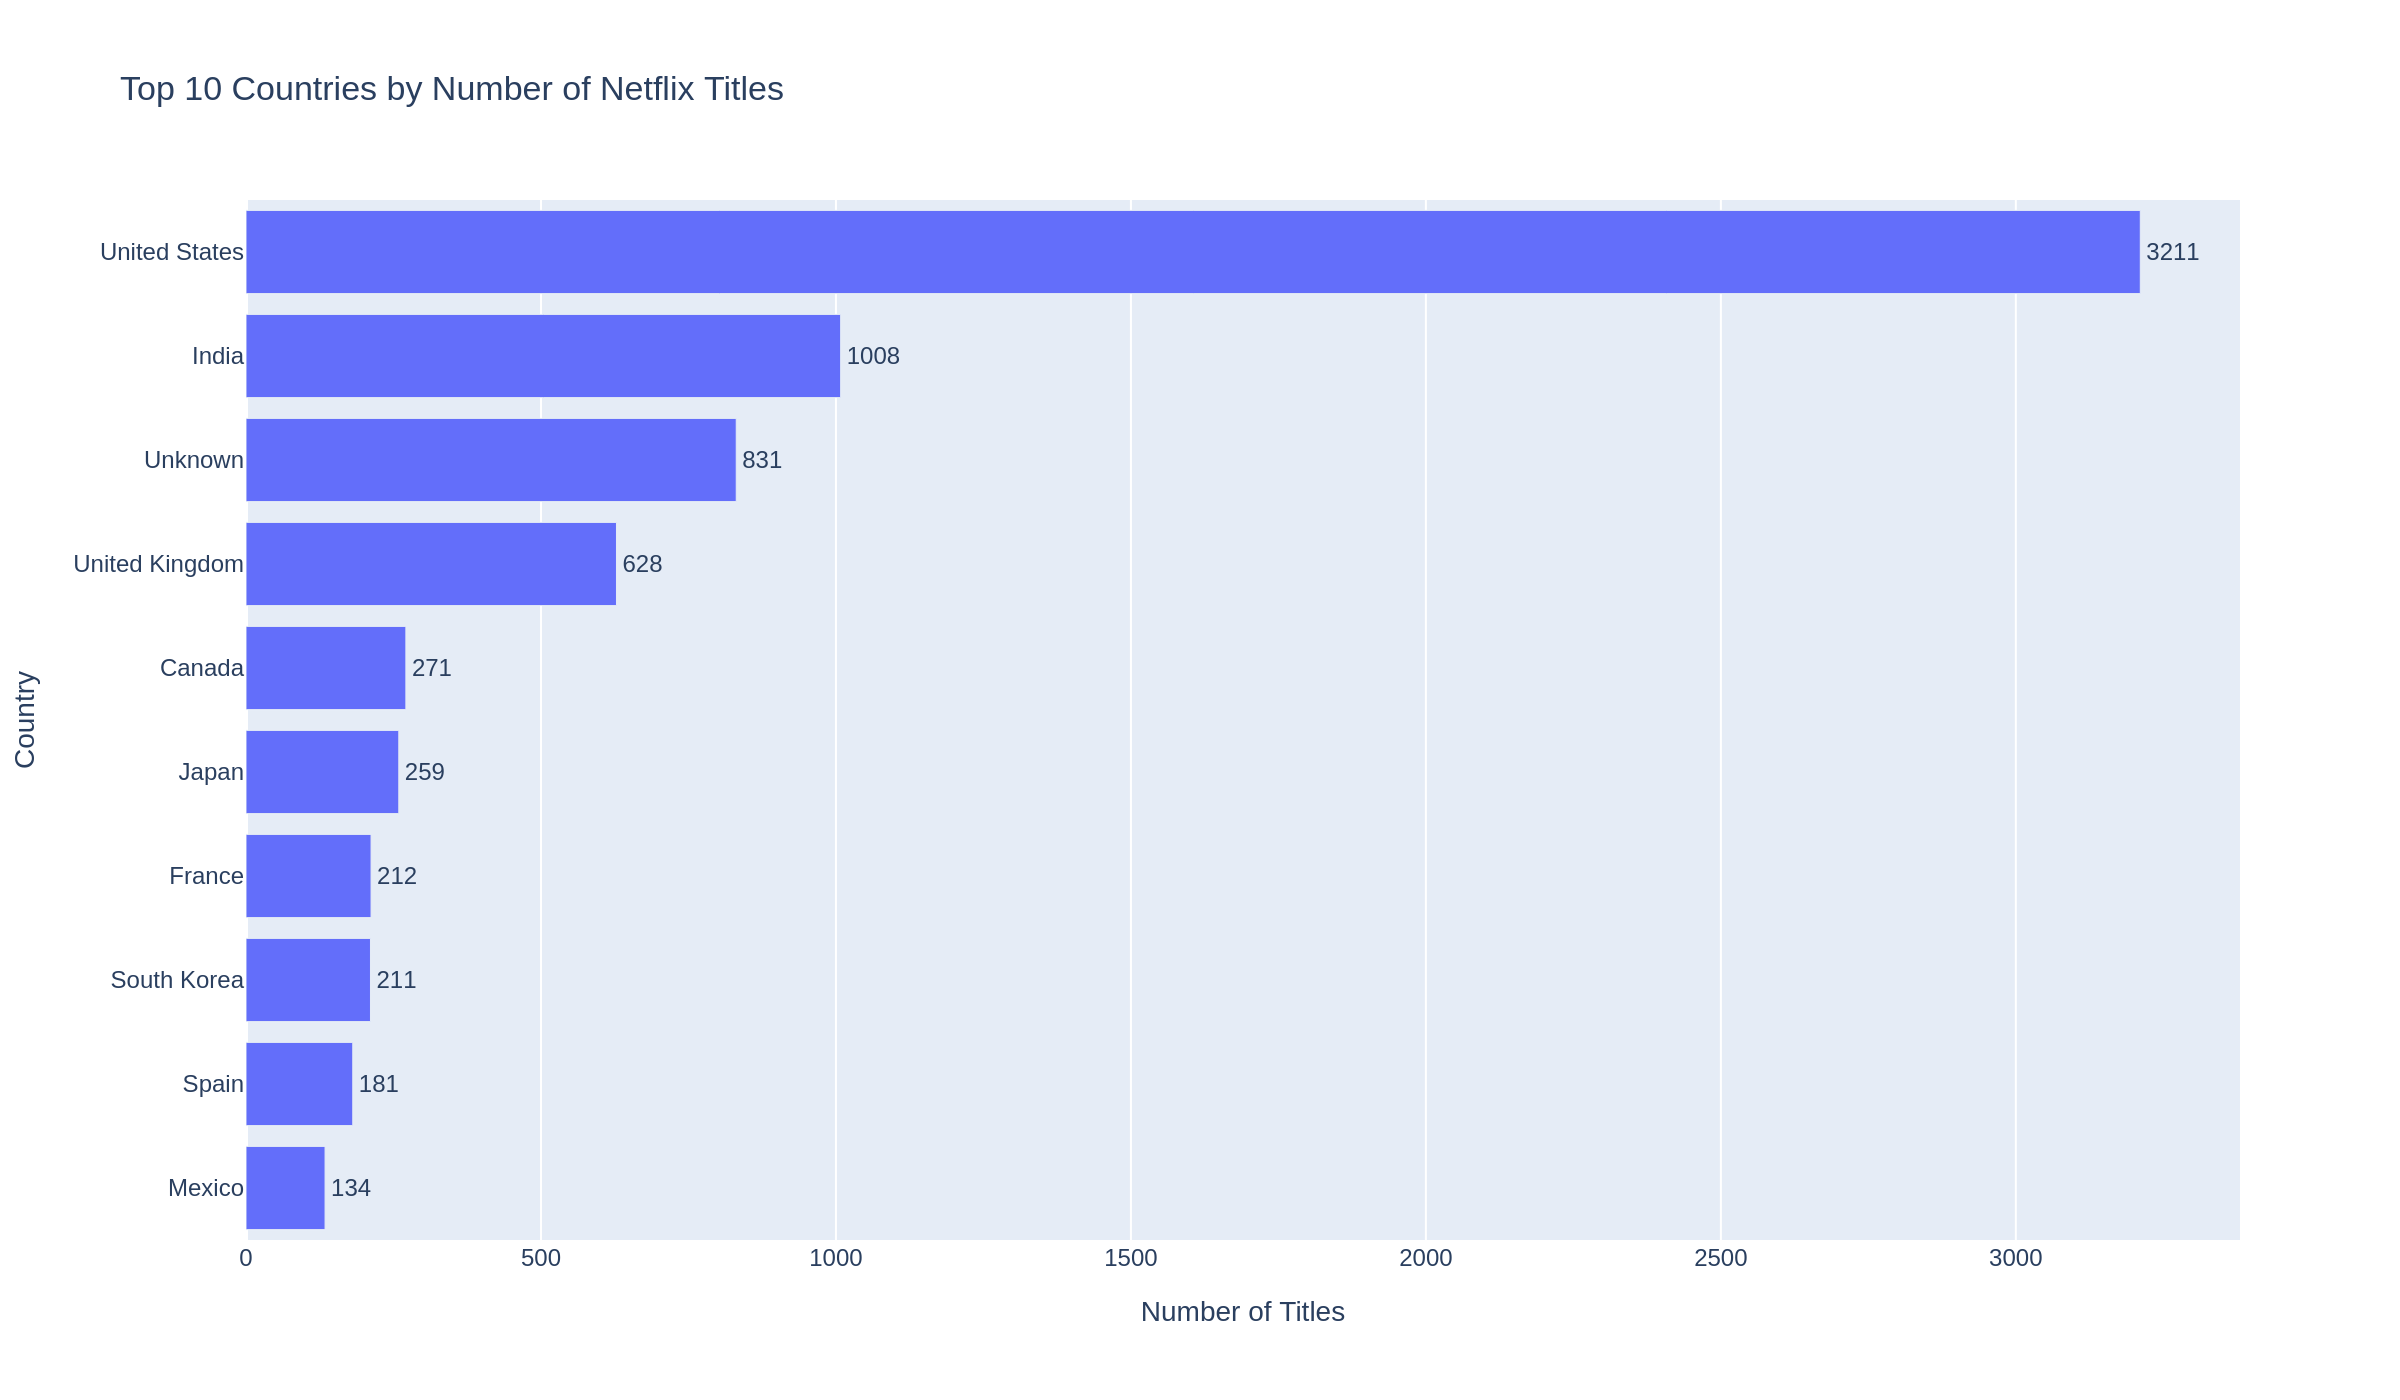

In [ ]:
top_countries = (
    eda_df["primary_country"]
    .value_counts()
    .head(10)
    .sort_values()
    .reset_index()
)

top_countries.columns = ["country", "titles"]

fig = px.bar(
    top_countries,
    x="titles",
    y="country",
    orientation="h",
    title="Top 10 Countries by Number of Netflix Titles",
    labels={
        "titles": "Number of Titles",
        "country": "Country"
    },
    text="titles"
)

fig.update_traces(textposition="outside")

fig.show()
display(Image(fig.to_image(format="png", width=1200, height=700, scale=2)))

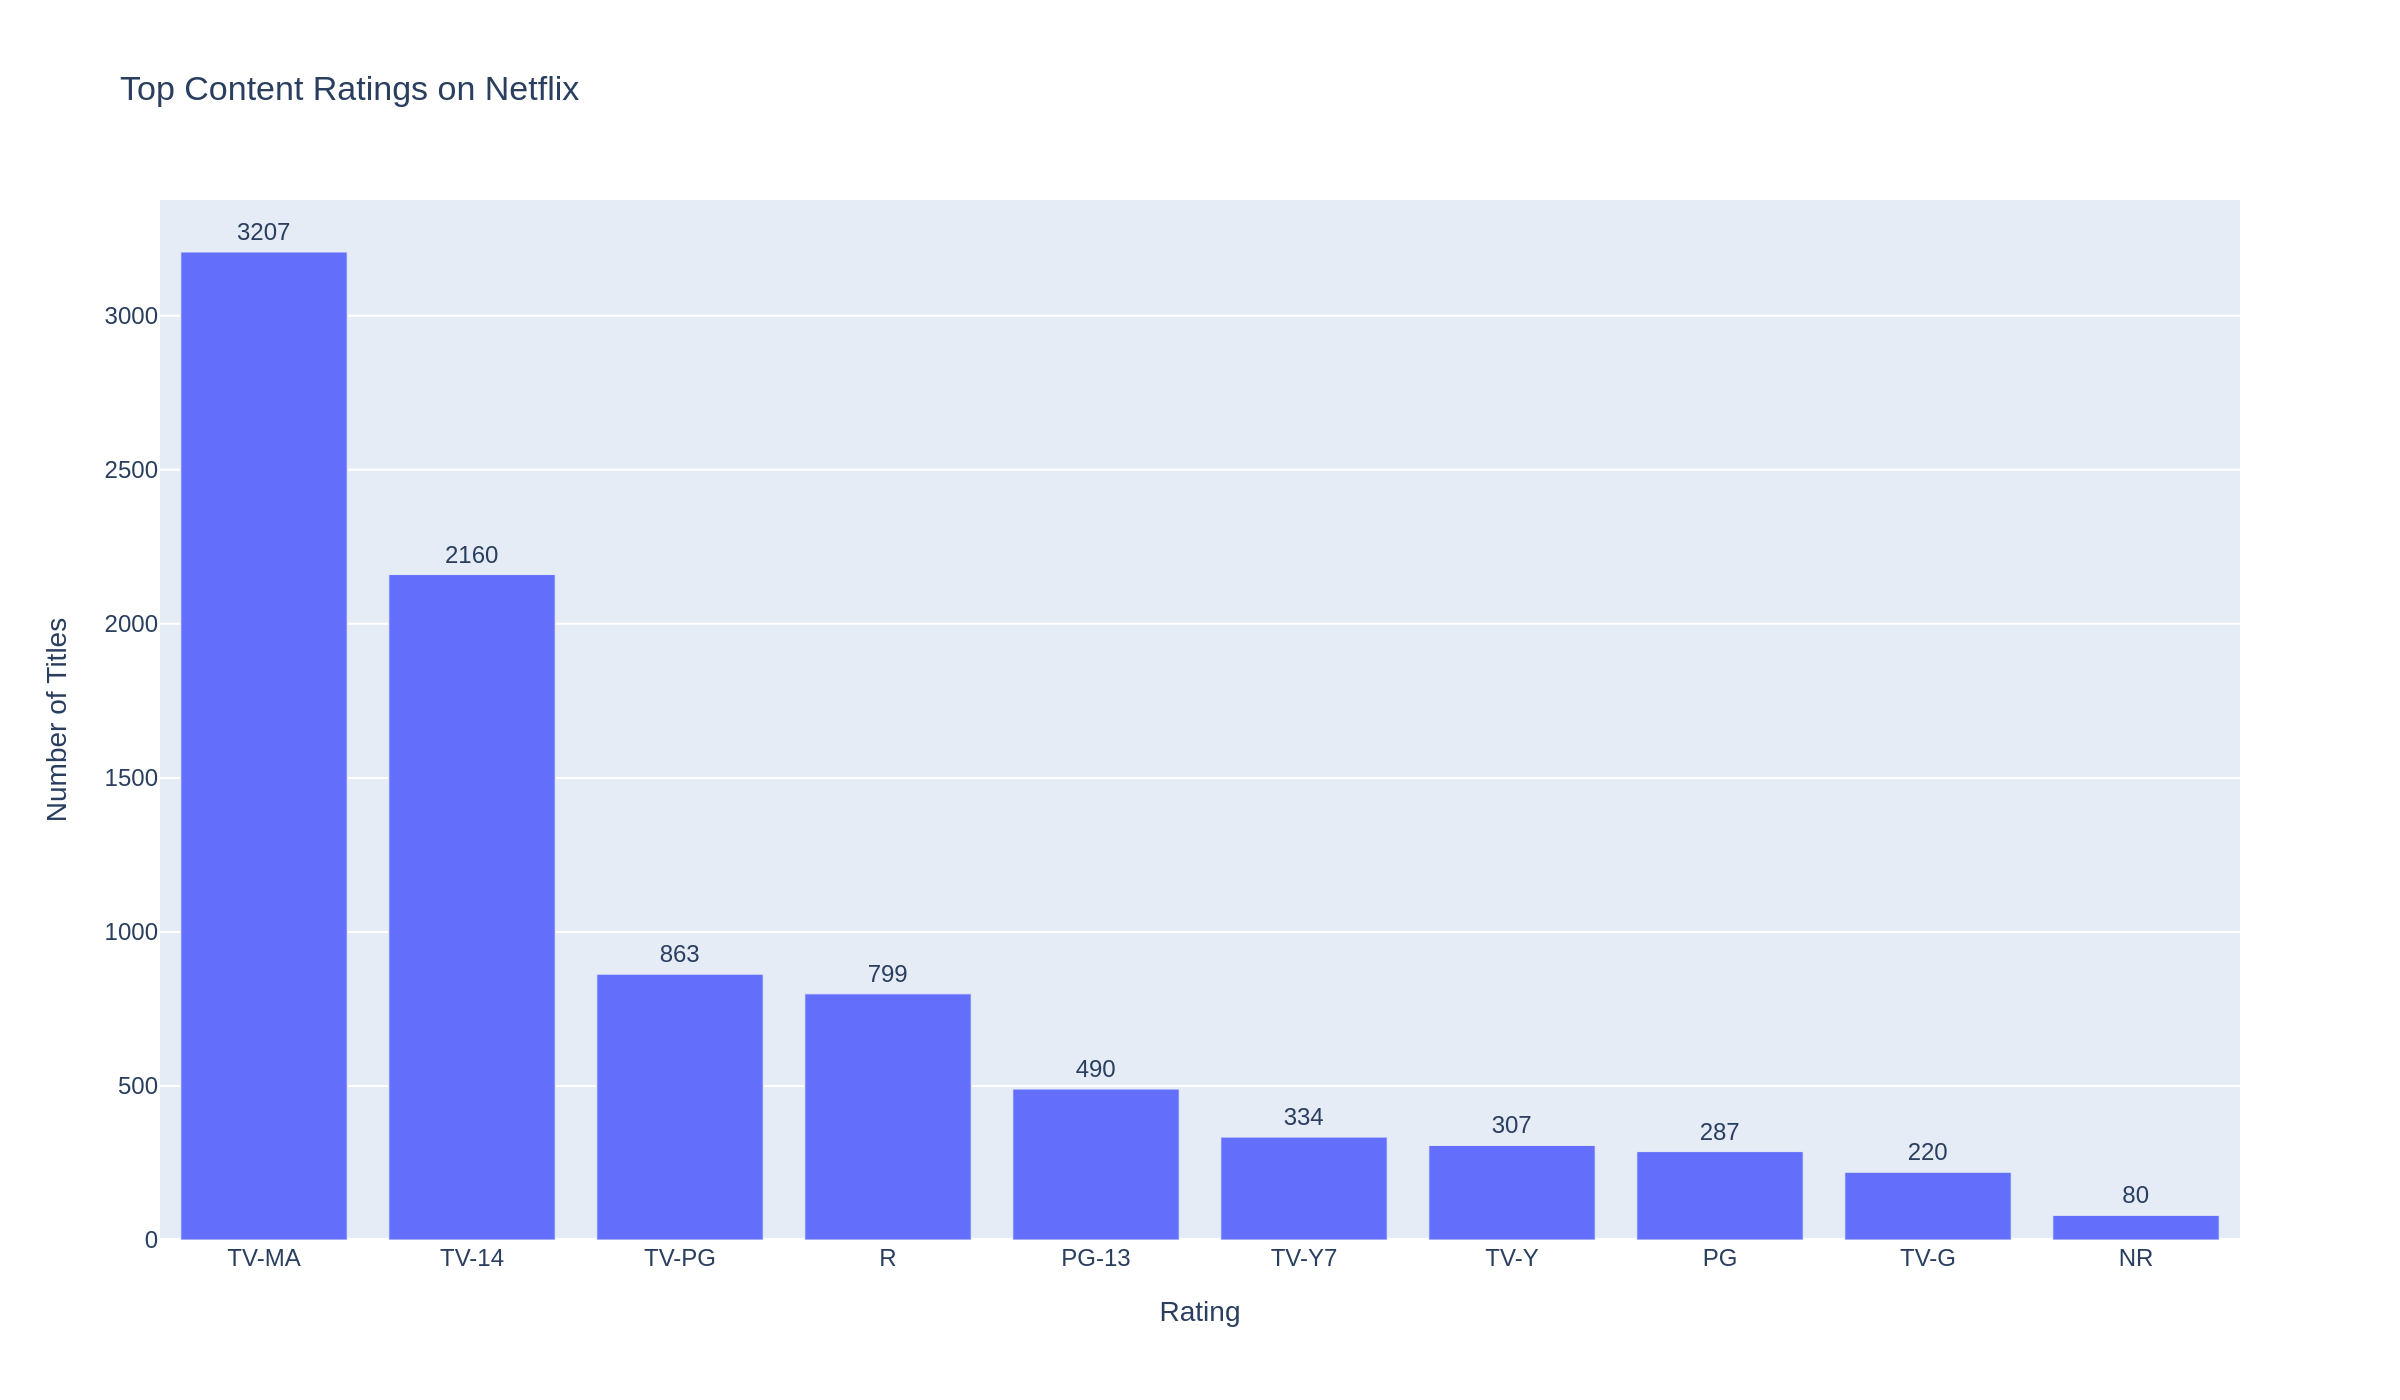

In [ ]:
top_ratings = (
    eda_df["rating"]
    .value_counts()
    .head(10)
    .reset_index()
)

top_ratings.columns = ["rating", "titles"]

fig = px.bar(
    top_ratings,
    x="rating",
    y="titles",
    title="Top Content Ratings on Netflix",
    labels={
        "rating": "Rating",
        "titles": "Number of Titles"
    },
    text="titles"
)

fig.update_traces(textposition="outside")

fig.show()
display(Image(fig.to_image(format="png", width=1200, height=700, scale=2)))

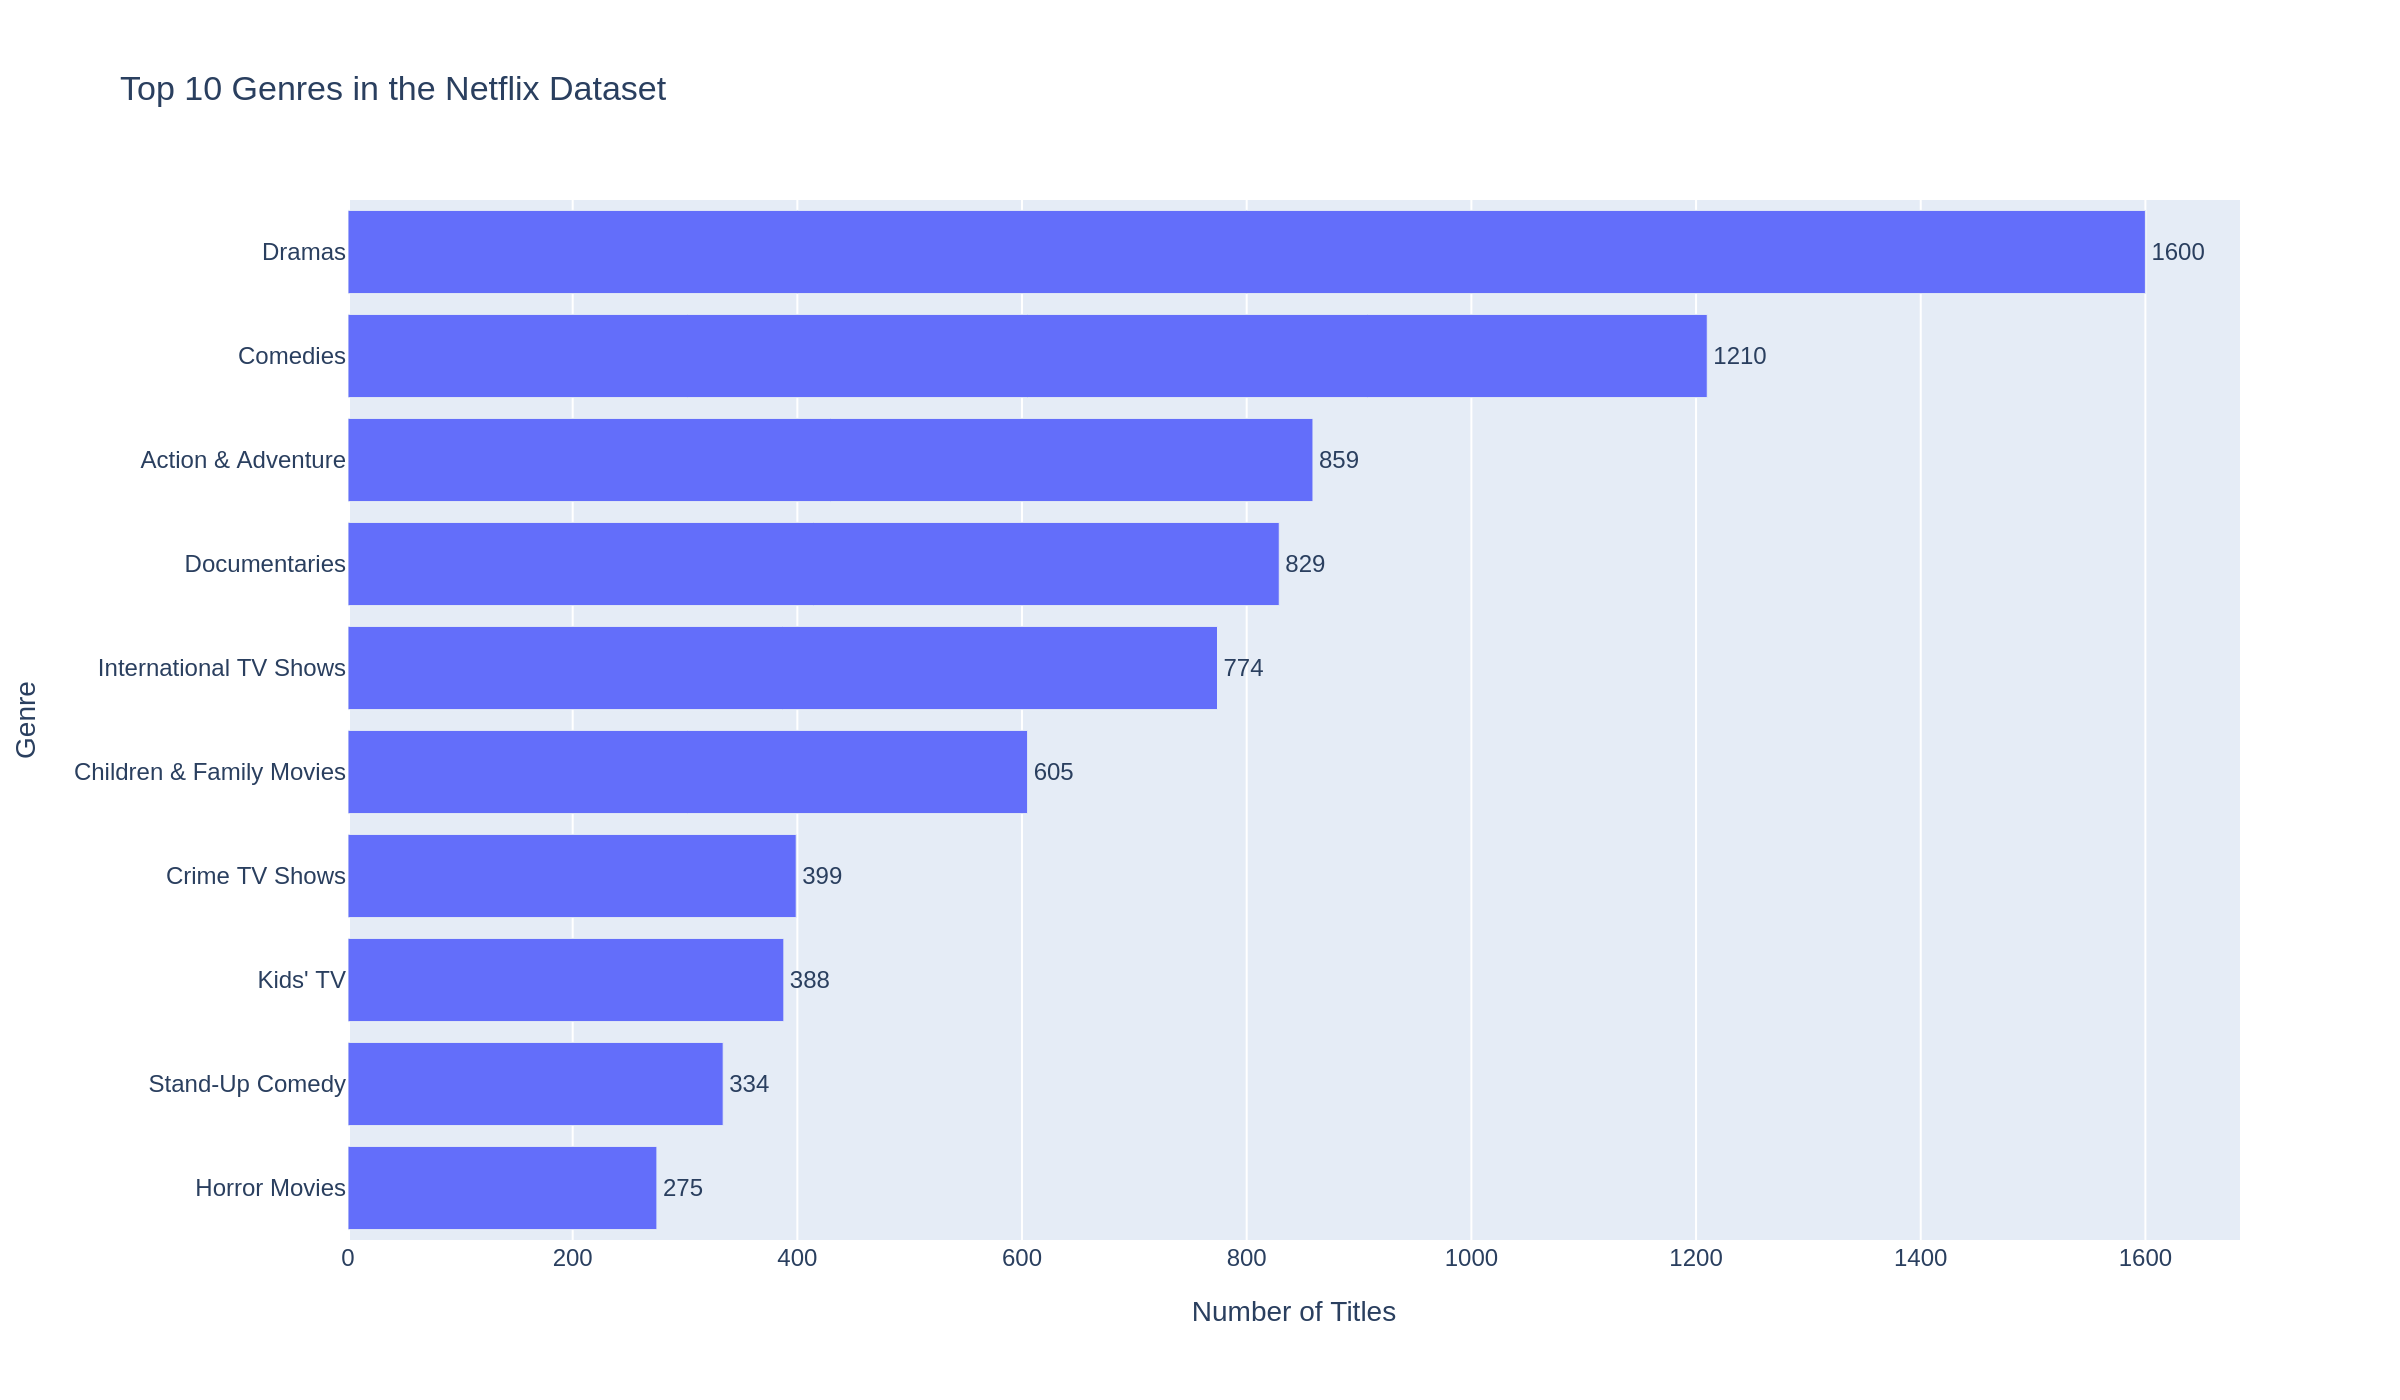

In [ ]:
top_genres = (
    eda_df["primary_genre"]
    .value_counts()
    .head(10)
    .sort_values()
    .reset_index()
)

top_genres.columns = ["genre", "titles"]

fig = px.bar(
    top_genres,
    x="titles",
    y="genre",
    orientation="h",
    title="Top 10 Genres in the Netflix Dataset",
    labels={
        "titles": "Number of Titles",
        "genre": "Genre"
    },
    text="titles"
)

fig.update_traces(textposition="outside")

fig.show()
display(Image(fig.to_image(format="png", width=1200, height=700, scale=2)))

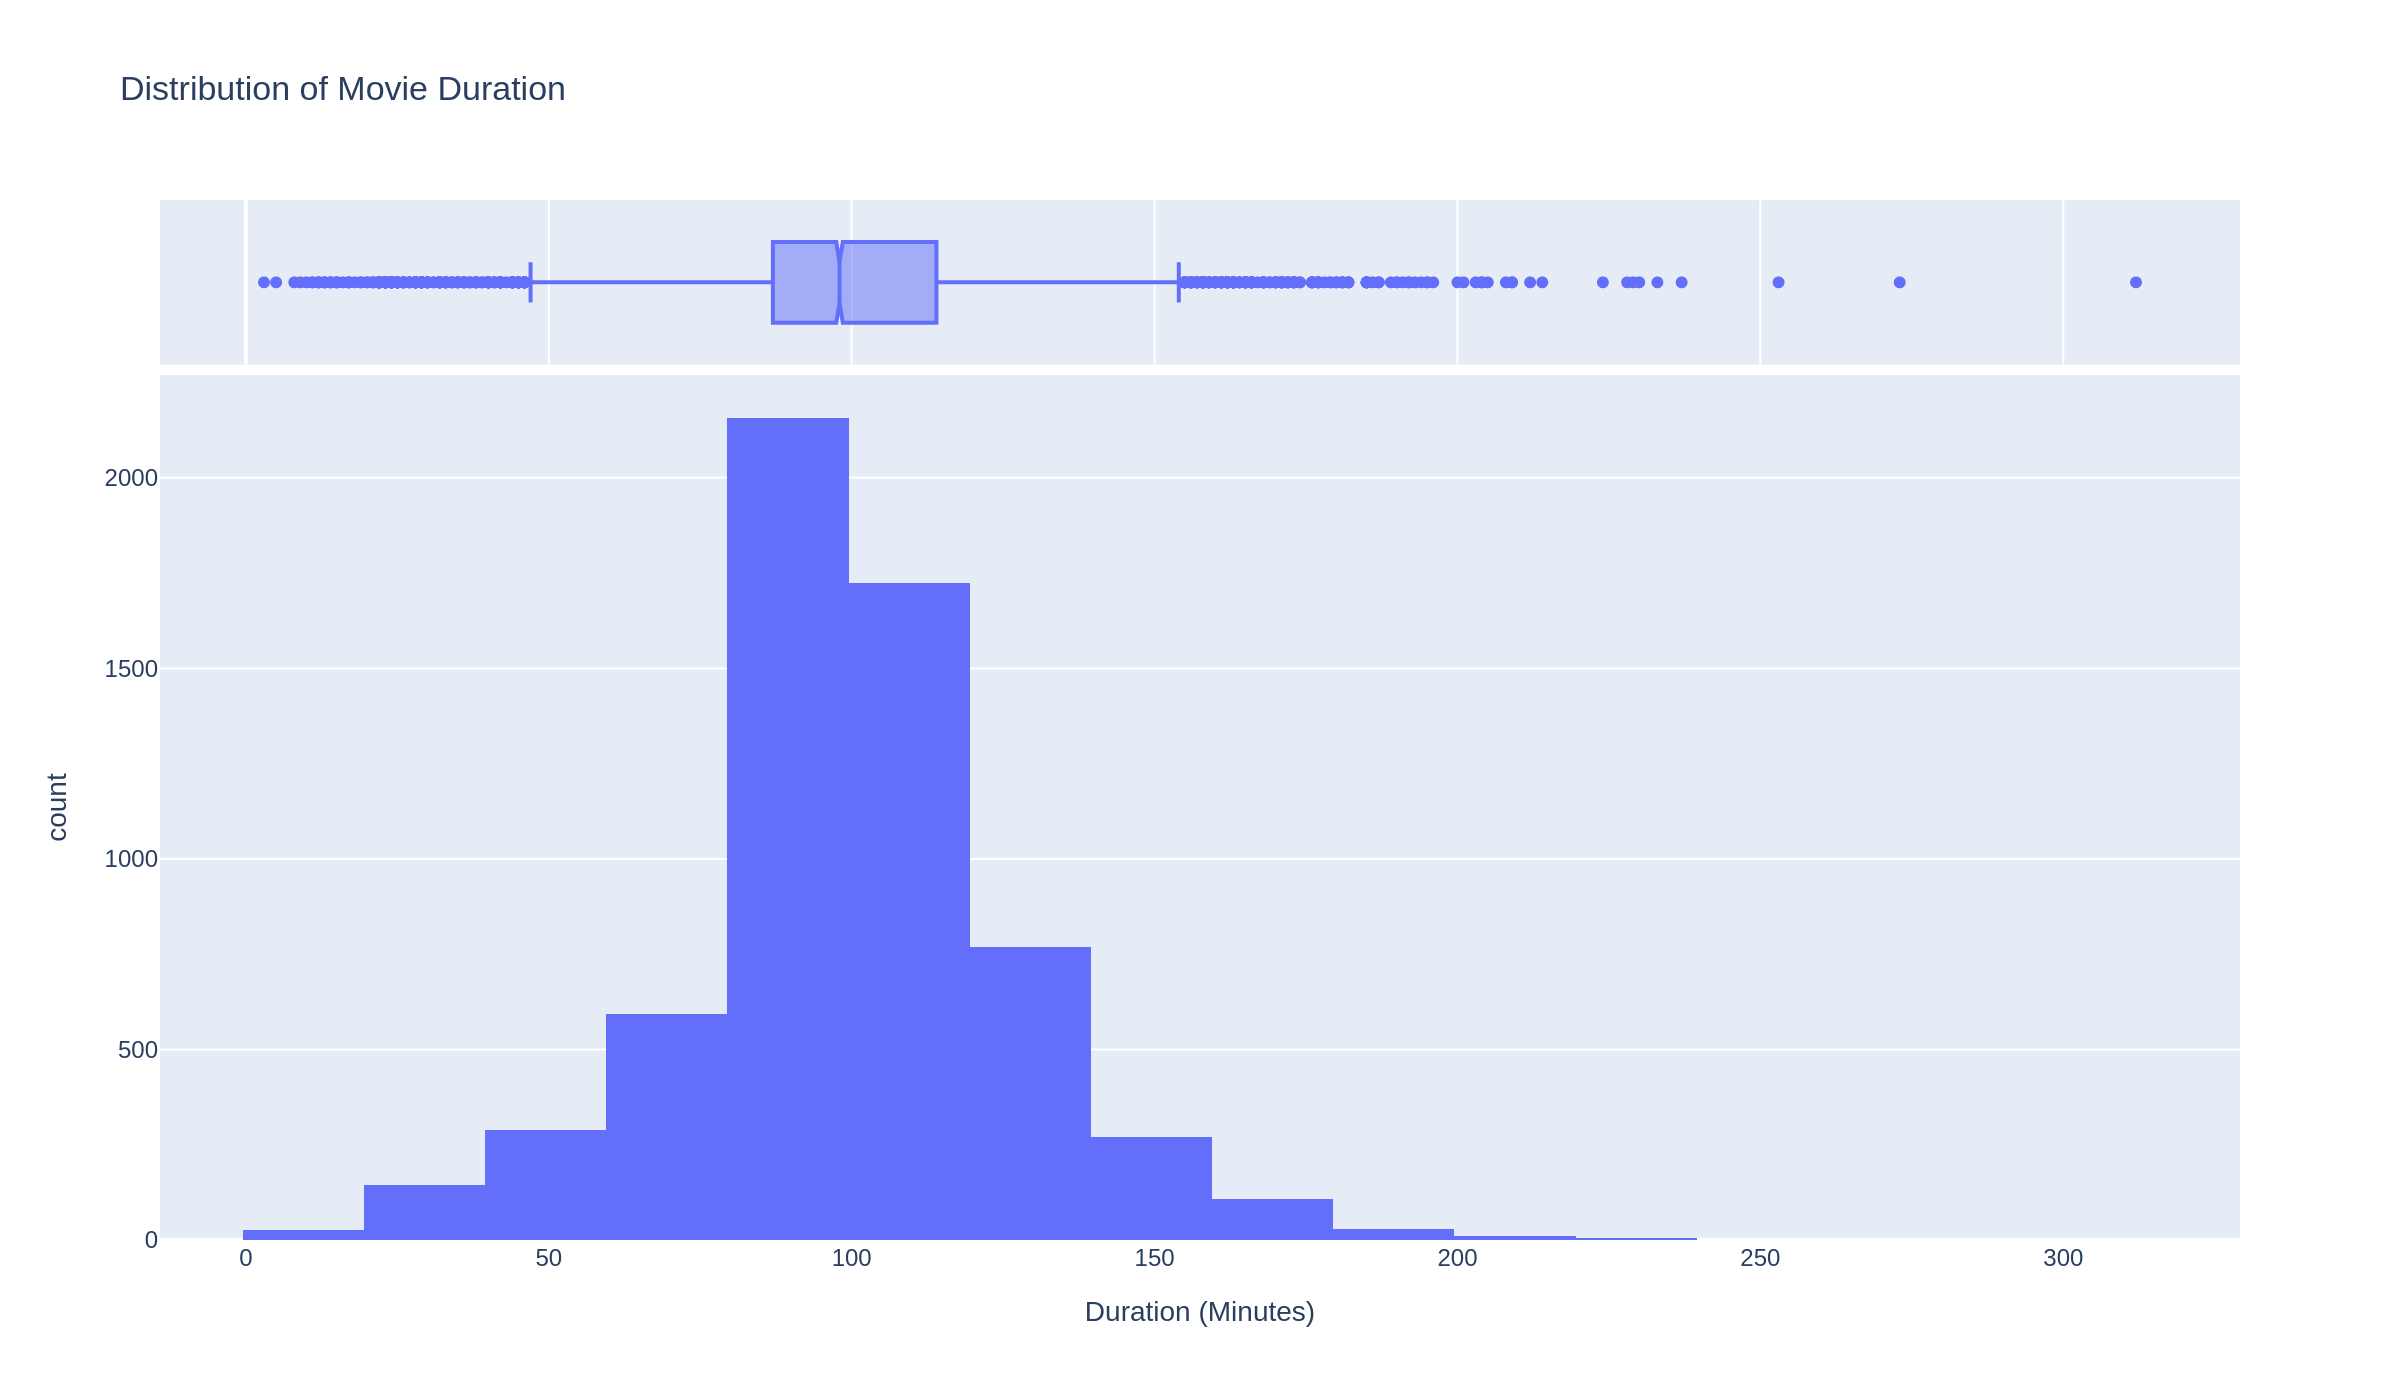

In [ ]:
movie_duration = eda_df[
    eda_df["type"] == "Movie"
].dropna(subset=["duration_minutes"])

fig = px.histogram(
    movie_duration,
    x="duration_minutes",
    nbins=30,
    marginal="box",
    title="Distribution of Movie Duration",
    labels={
        "duration_minutes": "Duration (Minutes)"
    }
)

fig.show()
display(Image(fig.to_image(format="png", width=1200, height=700, scale=2)))

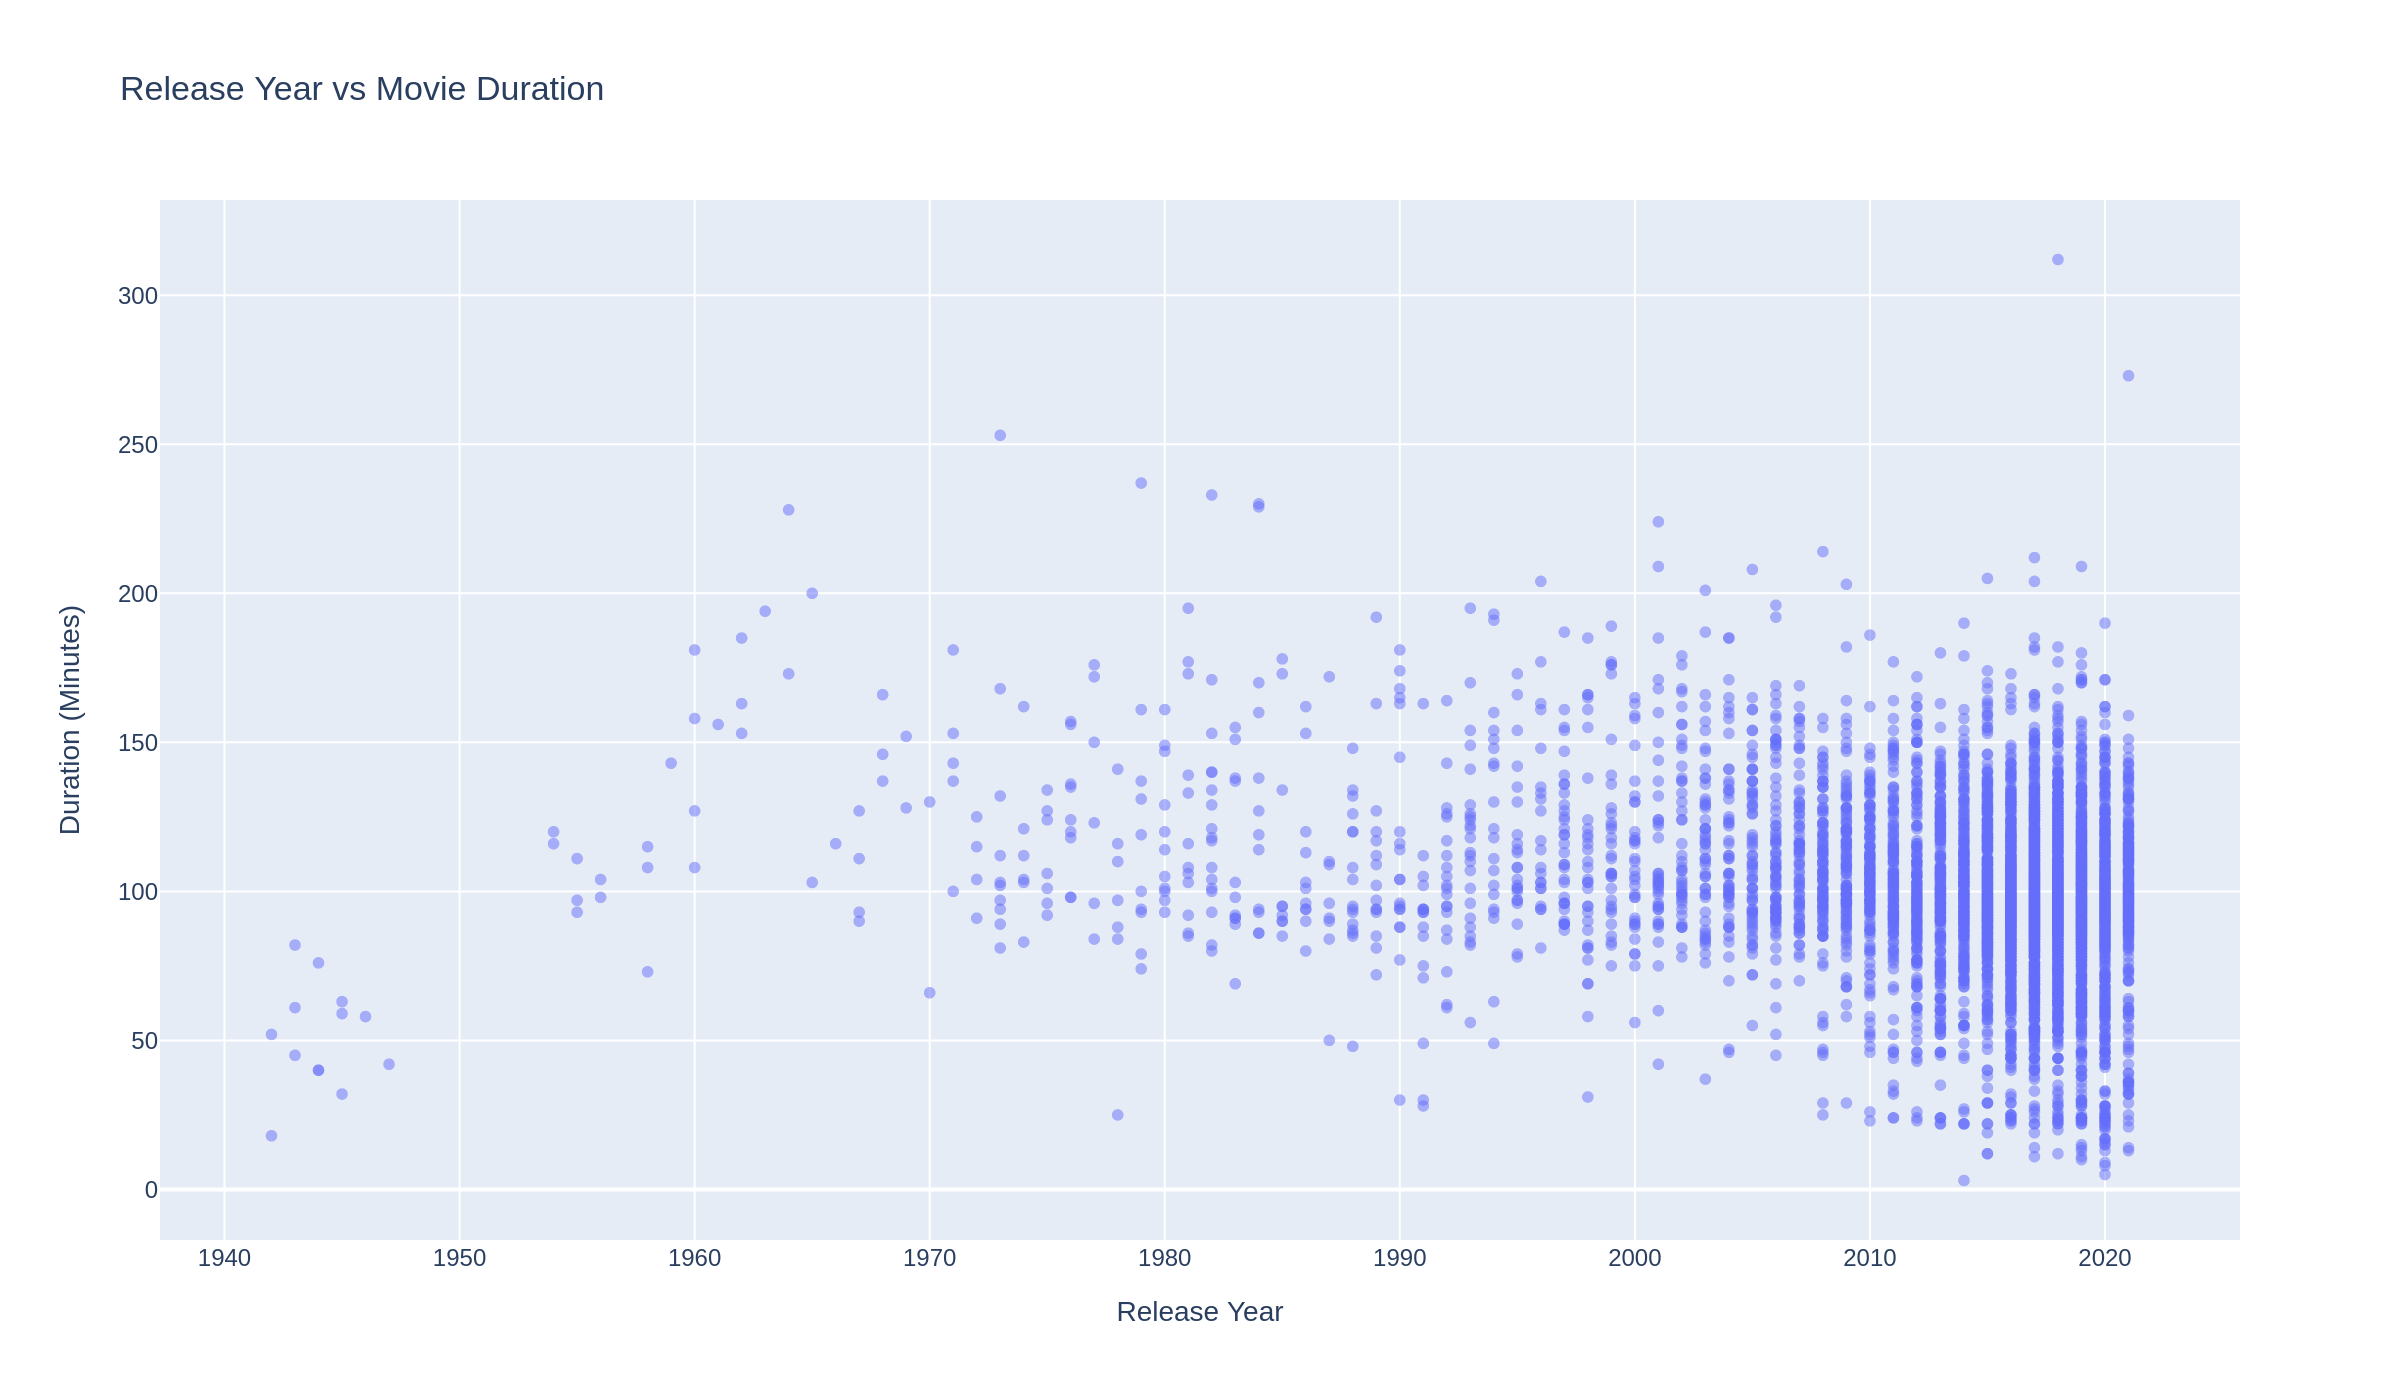

In [ ]:
scatter_df = eda_df[
    (eda_df["type"] == "Movie") &
    eda_df["release_year"].notna() &
    eda_df["duration_minutes"].notna()
].copy()

fig = px.scatter(
    scatter_df,
    x="release_year",
    y="duration_minutes",
    hover_name="title",
    opacity=0.5,
    title="Release Year vs Movie Duration",
    labels={
        "release_year": "Release Year",
        "duration_minutes": "Duration (Minutes)"
    }
)

fig.show()
display(Image(fig.to_image(format="png", width=1200, height=700, scale=2)))

In [ ]:
correlation_data = eda_df[
    [
        "release_year",
        "date_added_year",
        "duration_minutes",
        "duration_seasons",
        "num_genres",
        "num_countries"
    ]
]

correlation_matrix = correlation_data.corr()

correlation_matrix

,release_year,date_added_year,duration_minutes,duration_seasons,num_genres,num_countries
release_year,1.000000,0.110473,-0.206285,-0.090194,-0.040877,-0.072946
date_added_year,0.110473,1.000000,0.124436,0.106543,0.048913,-0.075074
duration_minutes,-0.206285,0.124436,1.000000,NaN,0.413998,0.085912
duration_seasons,-0.090194,0.106543,NaN,1.000000,-0.077864,0.116376
num_genres,-0.040877,0.048913,0.413998,-0.077864,1.000000,0.011488
num_countries,-0.072946,-0.075074,0.085912,0.116376,0.011488,1.000000


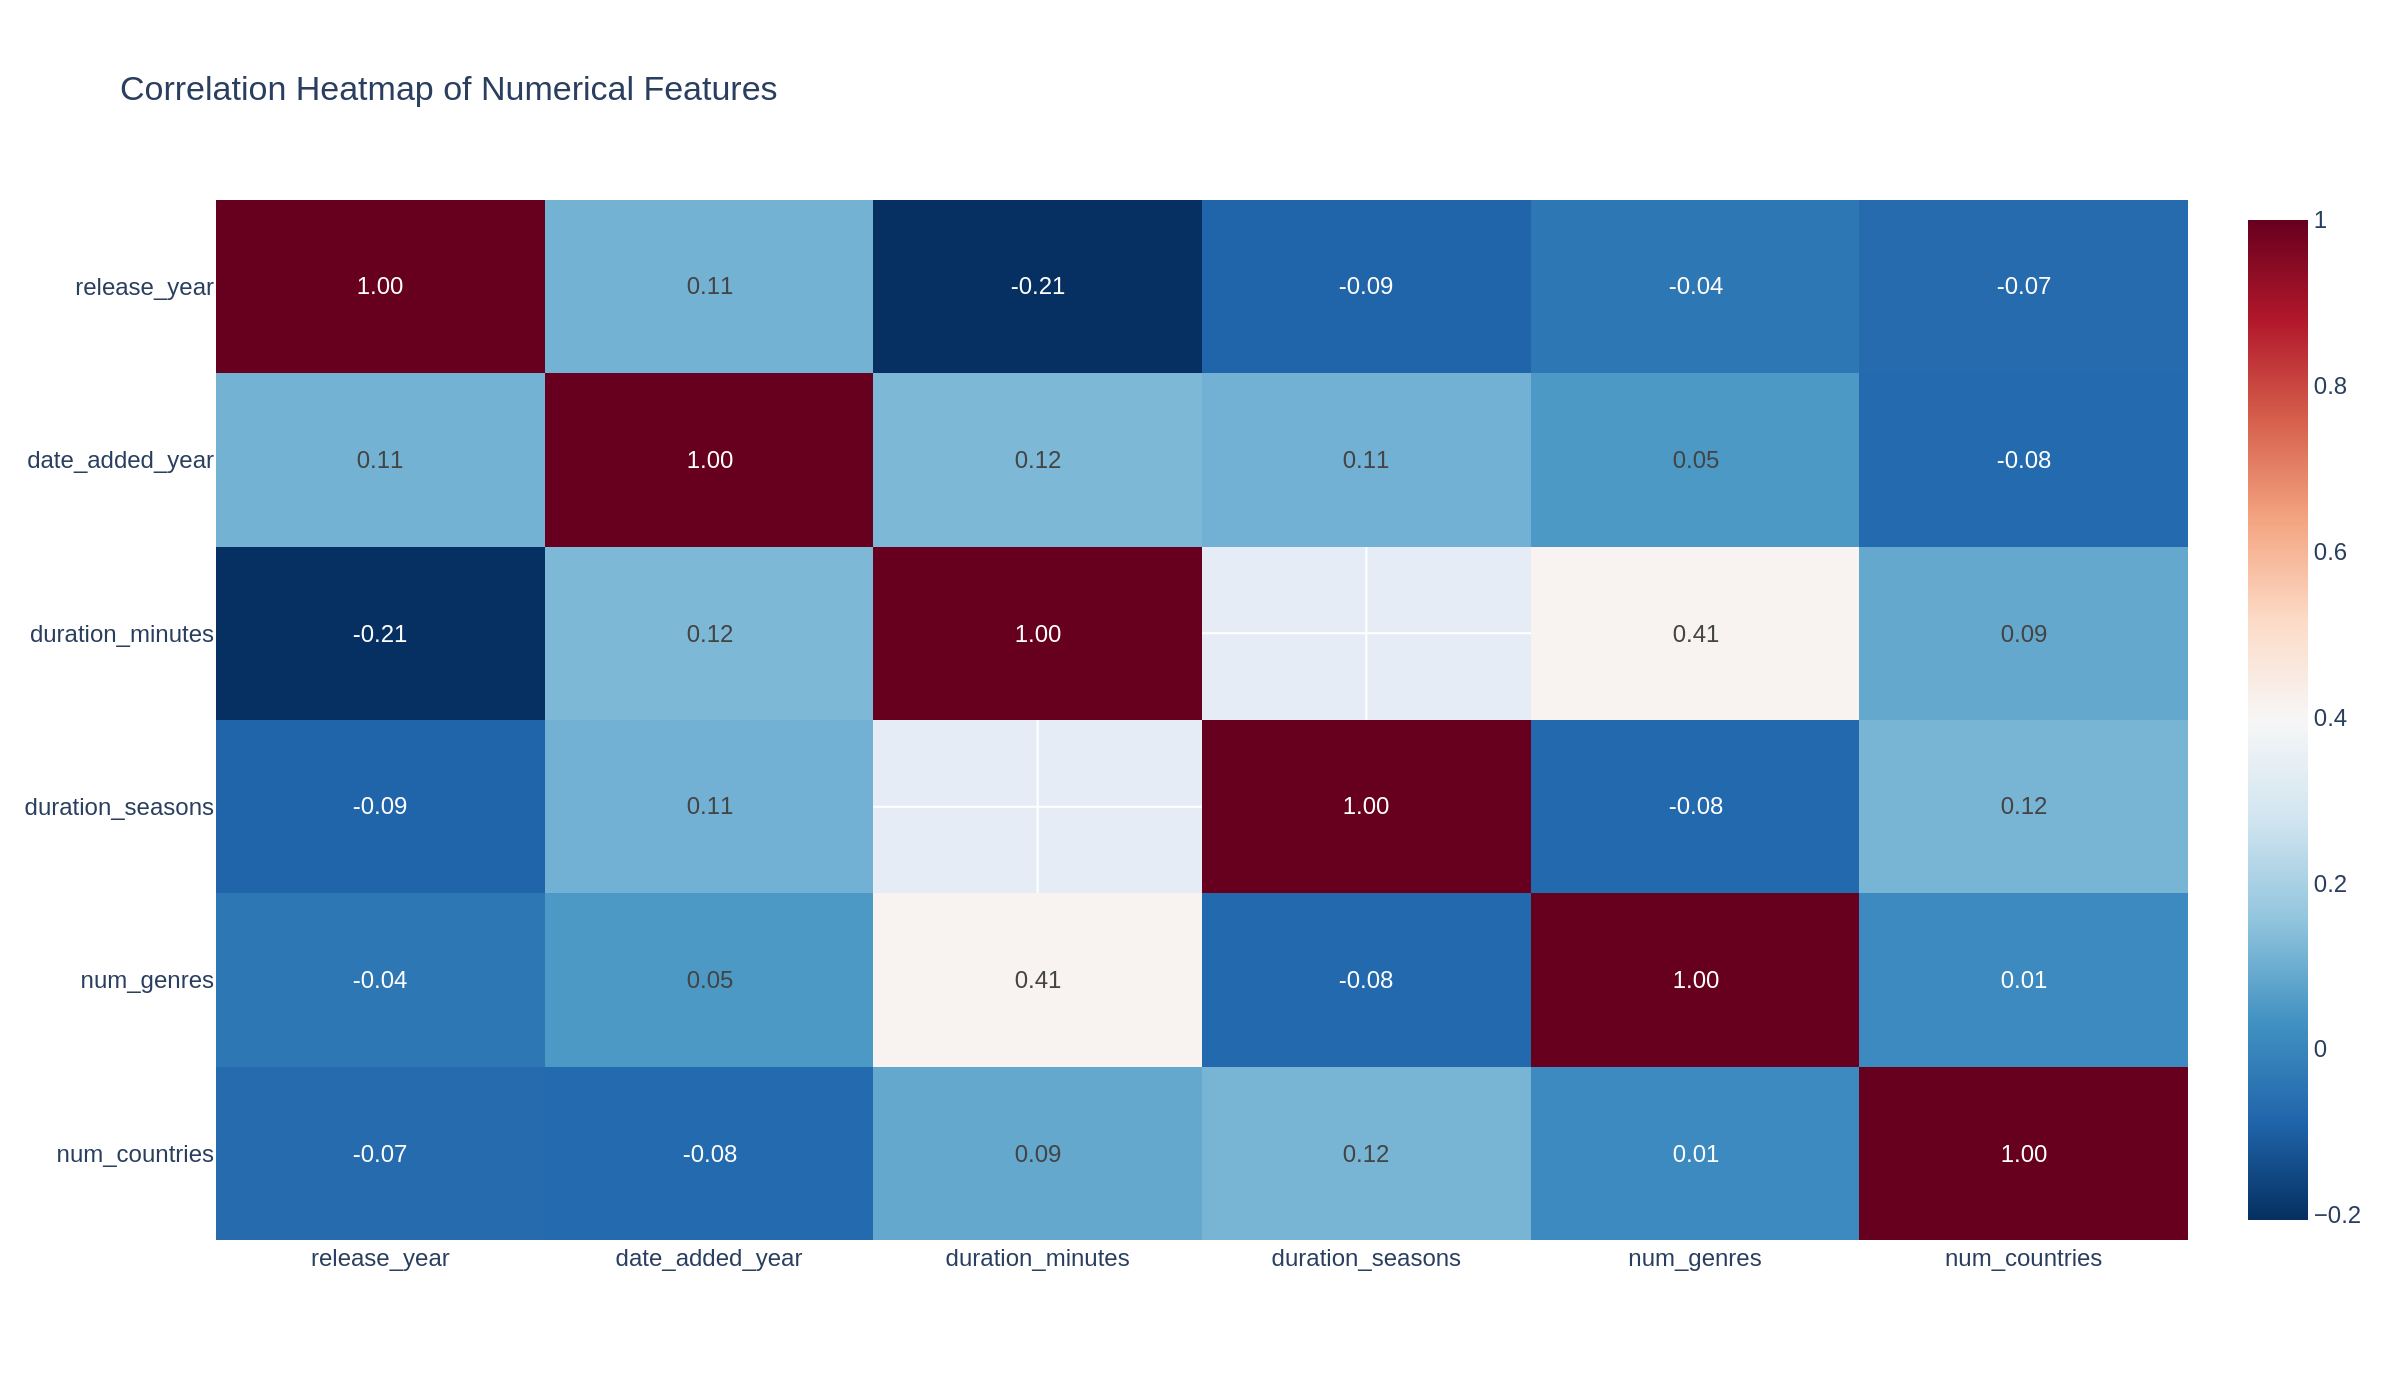

In [ ]:
fig = px.imshow(
    correlation_matrix,
    text_auto=".2f",
    aspect="auto",
    title="Correlation Heatmap of Numerical Features",
    color_continuous_scale="RdBu_r"
)

fig.show()
display(Image(fig.to_image(format="png", width=1200, height=700, scale=2)))

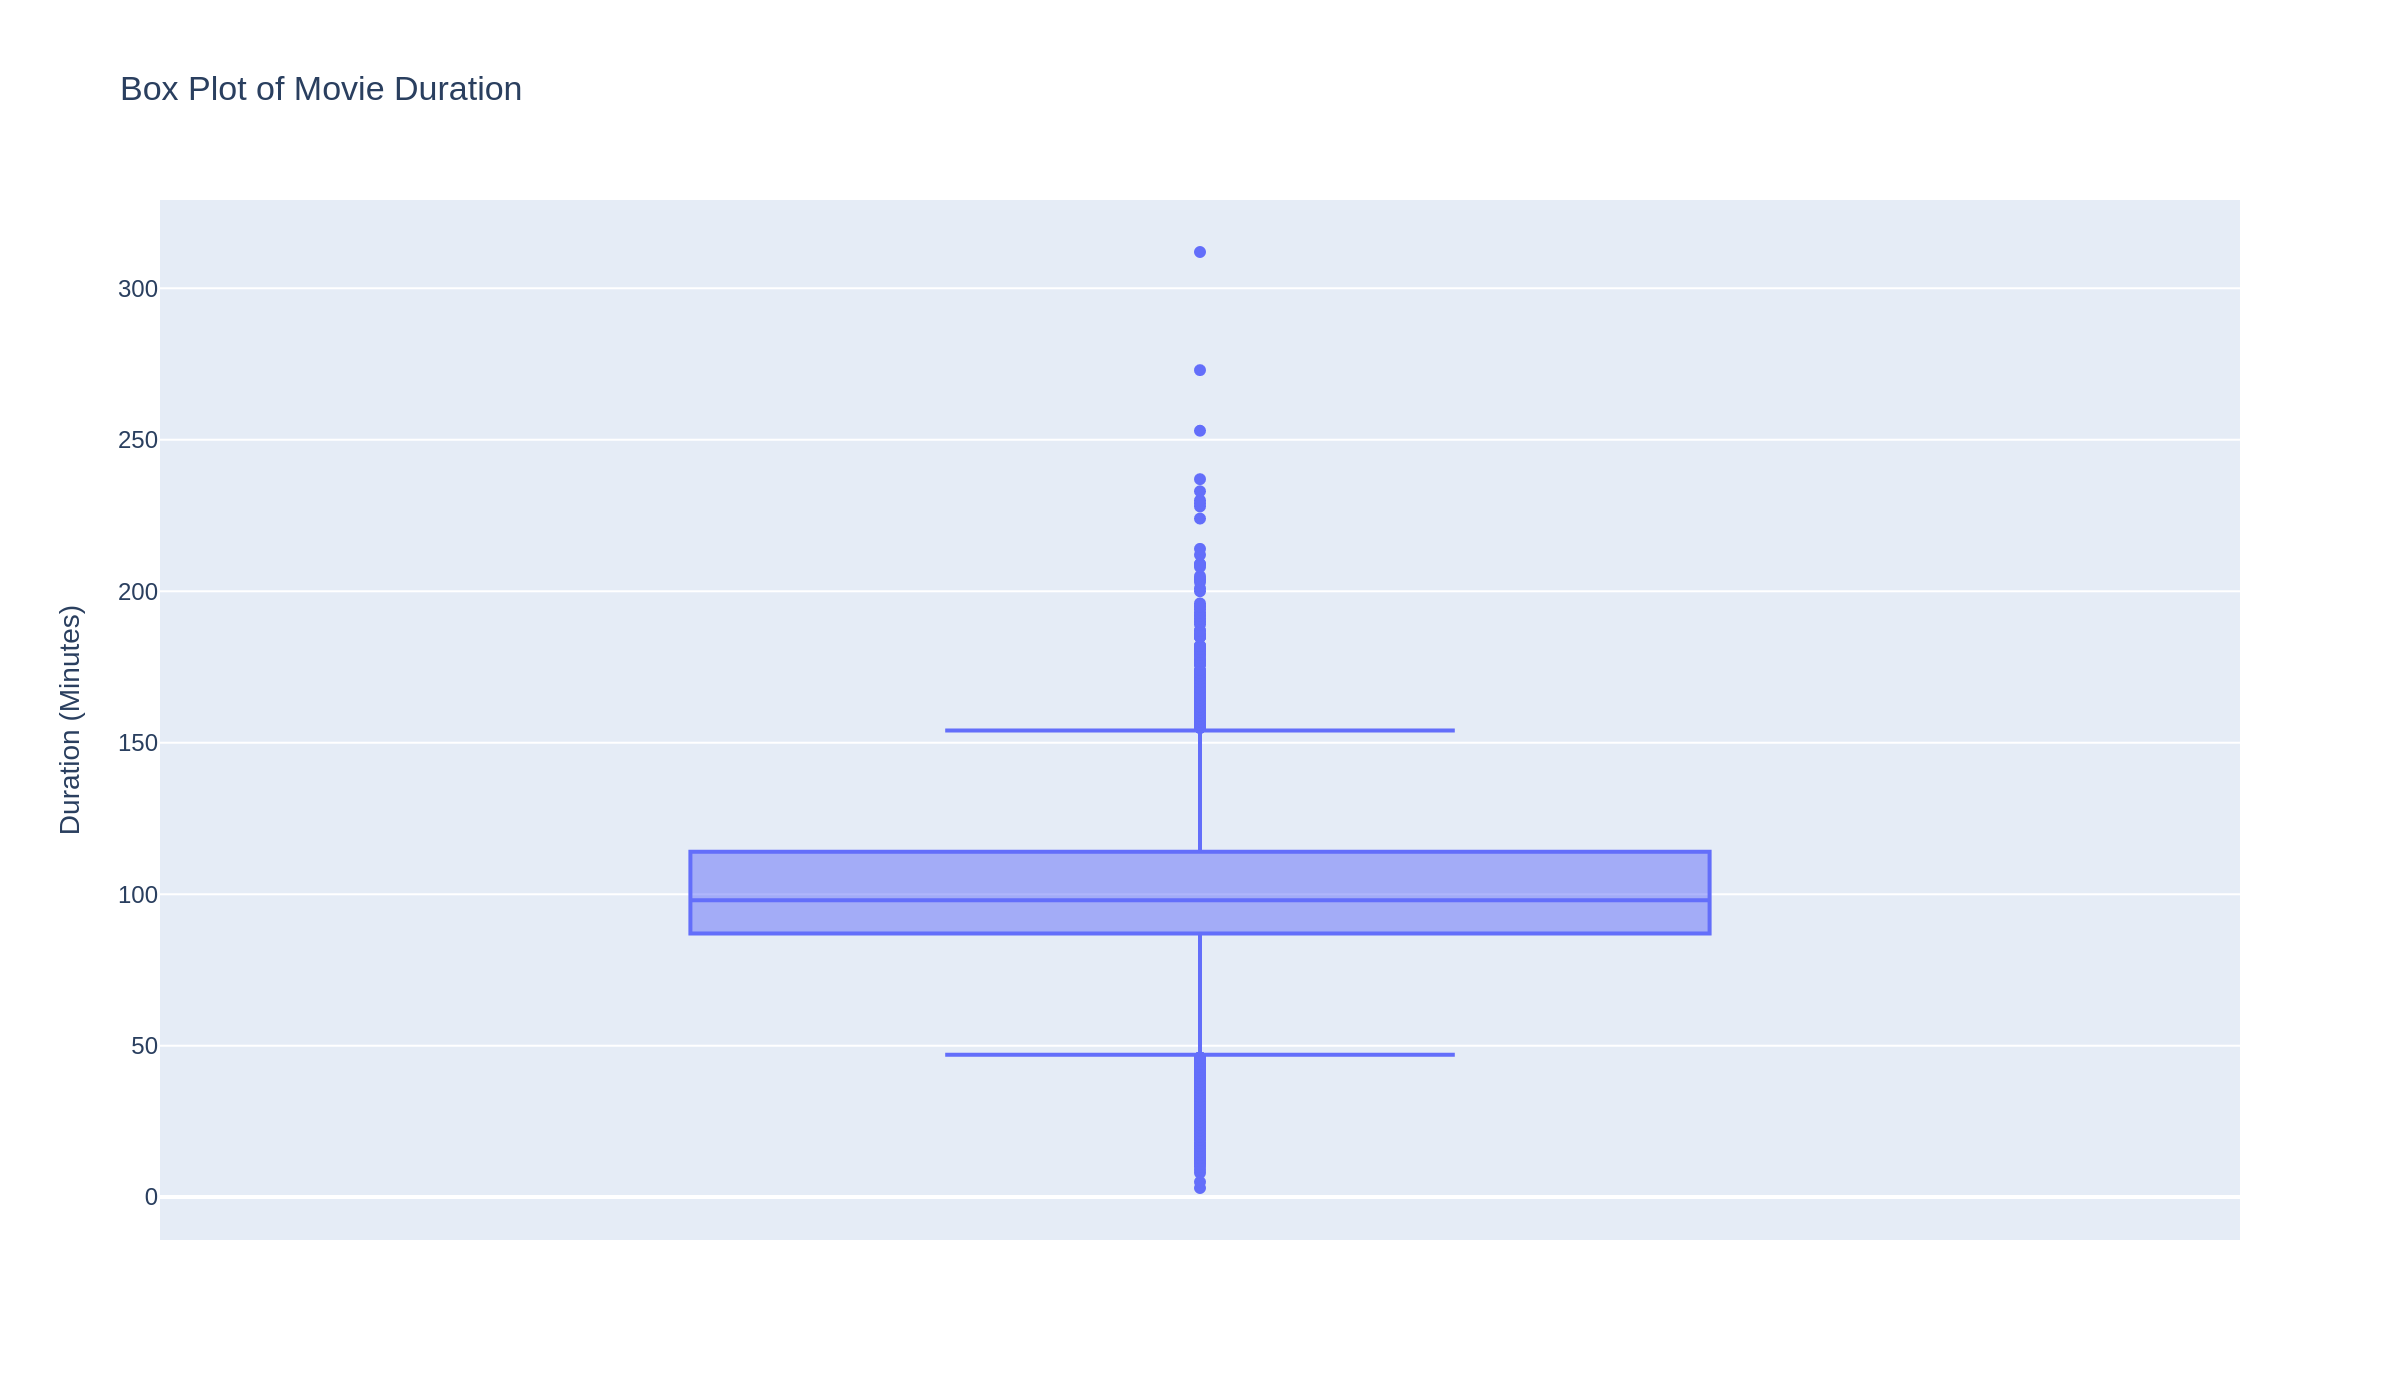

In [ ]:
fig = px.box(
    movie_duration,
    y="duration_minutes",
    title="Box Plot of Movie Duration",
    labels={
        "duration_minutes": "Duration (Minutes)"
    }
)

fig.show()
display(Image(fig.to_image(format="png", width=1200, height=700, scale=2)))

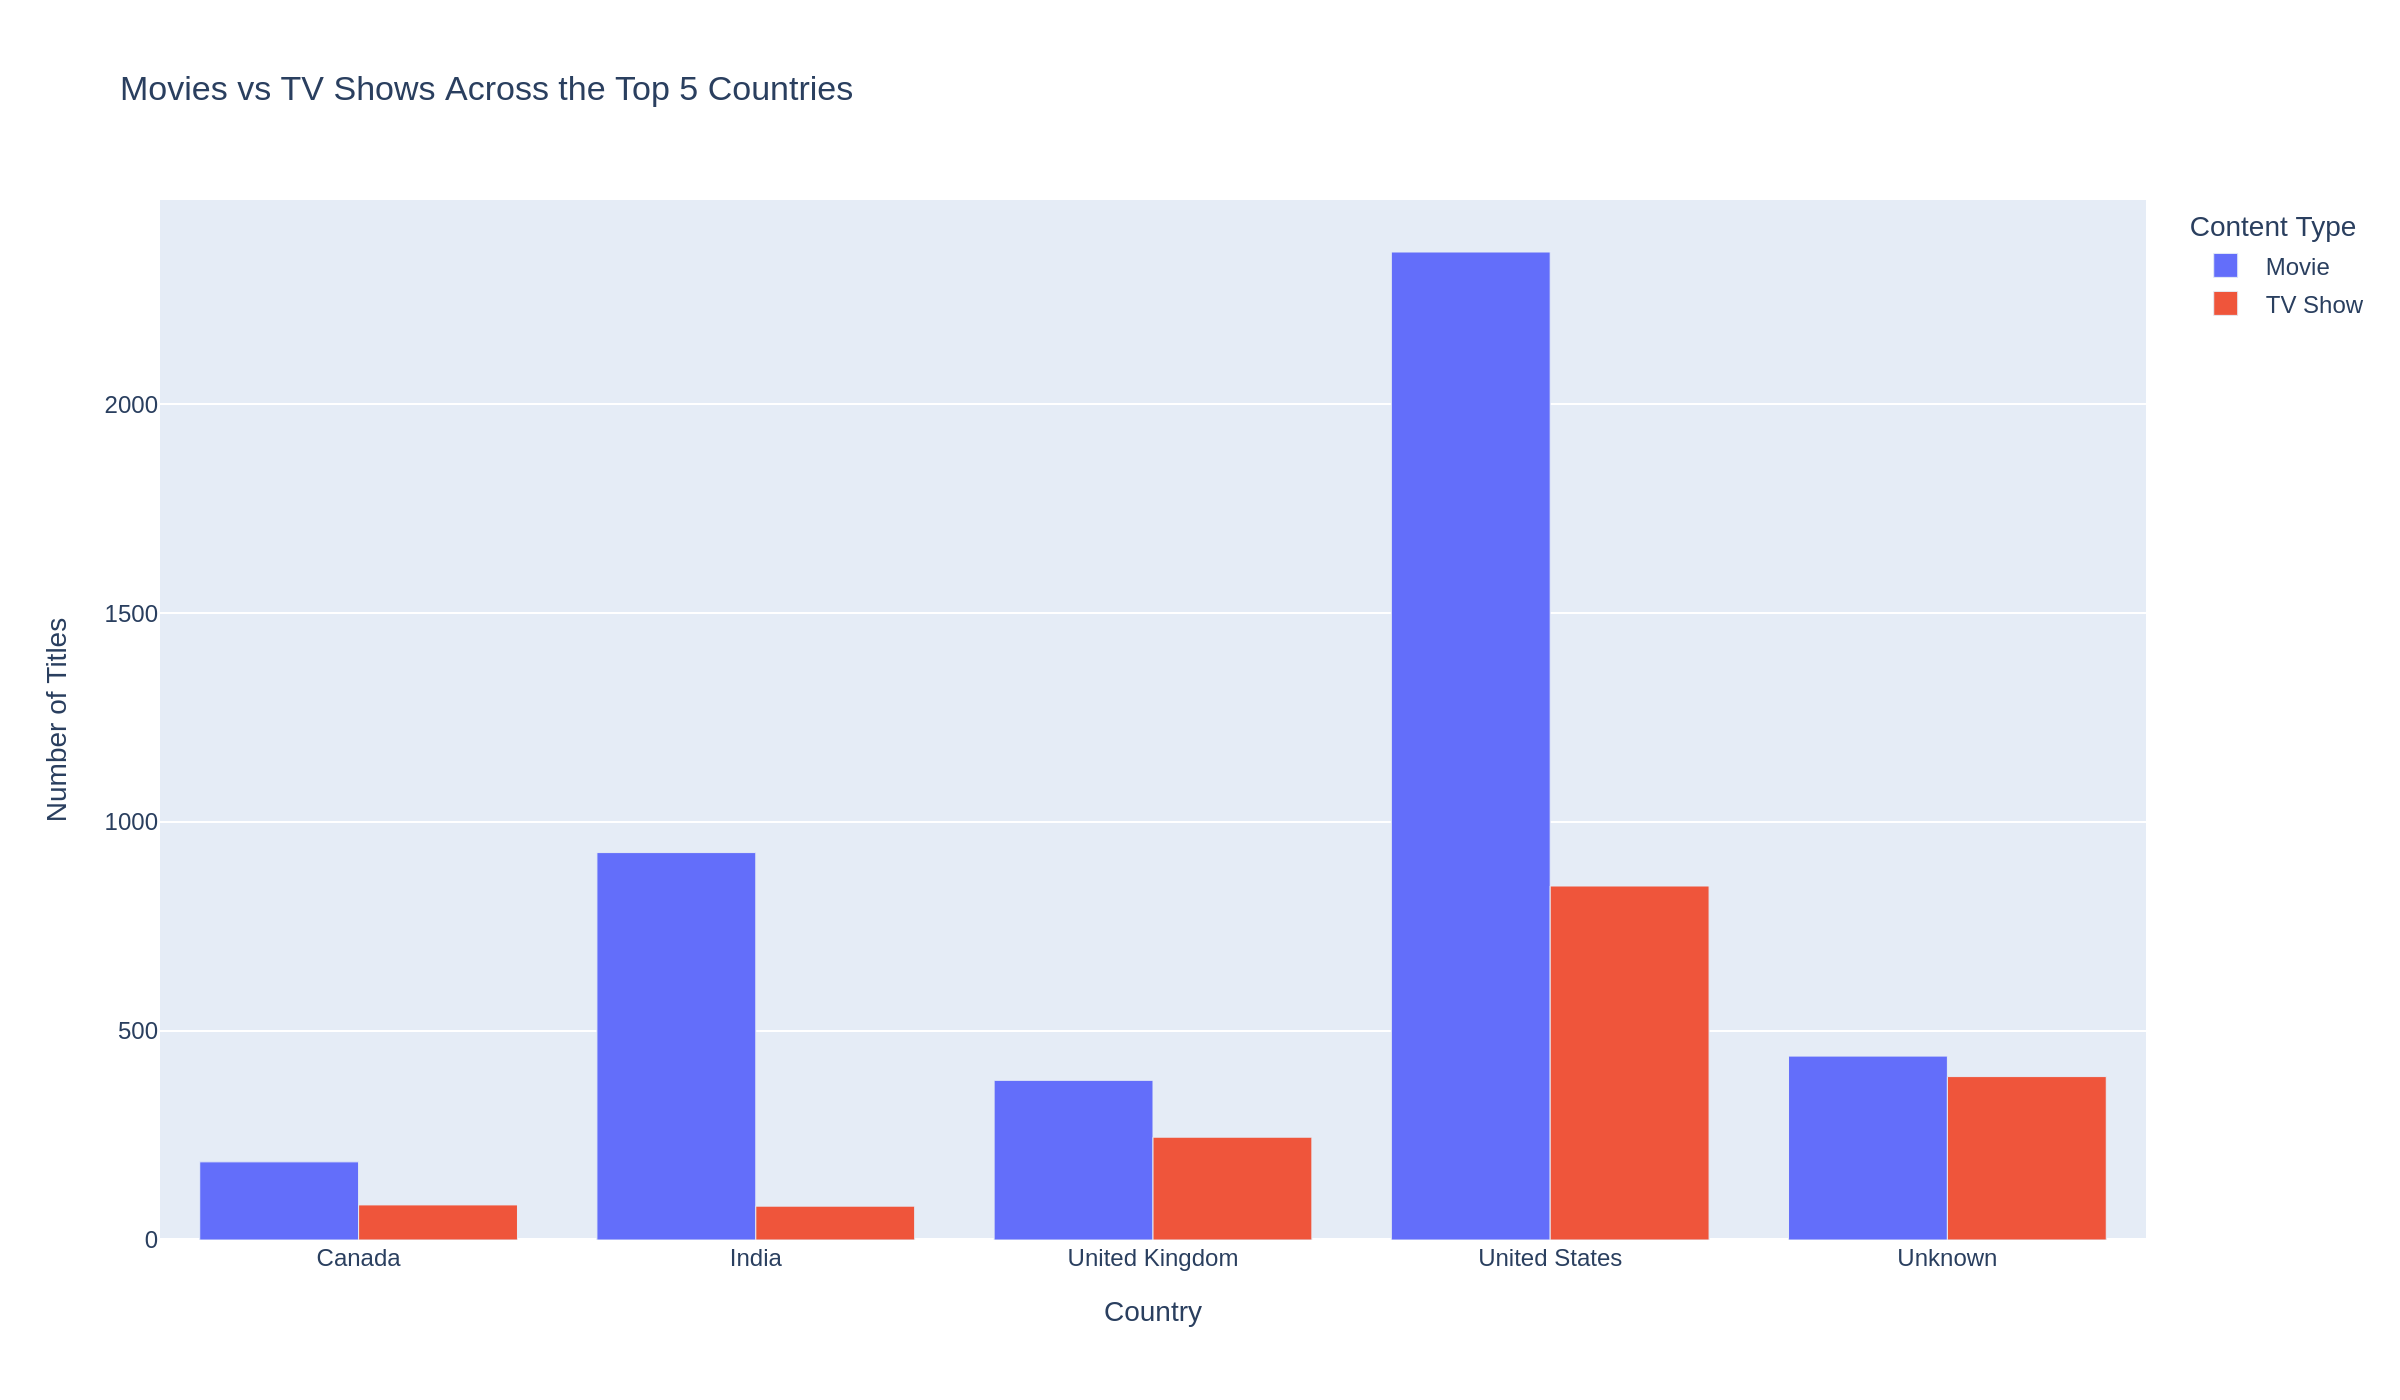

In [ ]:
top_5_countries = (
    eda_df["primary_country"]
    .value_counts()
    .head(5)
    .index
)

country_type_df = eda_df[
    eda_df["primary_country"].isin(top_5_countries)
]

country_type_counts = (
    country_type_df
    .groupby(["primary_country", "type"])
    .size()
    .reset_index(name="titles")
)

fig = px.bar(
    country_type_counts,
    x="primary_country",
    y="titles",
    color="type",
    barmode="group",
    title="Movies vs TV Shows Across the Top 5 Countries",
    labels={
        "primary_country": "Country",
        "titles": "Number of Titles",
        "type": "Content Type"
    }
)

fig.show()
display(Image(fig.to_image(format="png", width=1200, height=700, scale=2)))

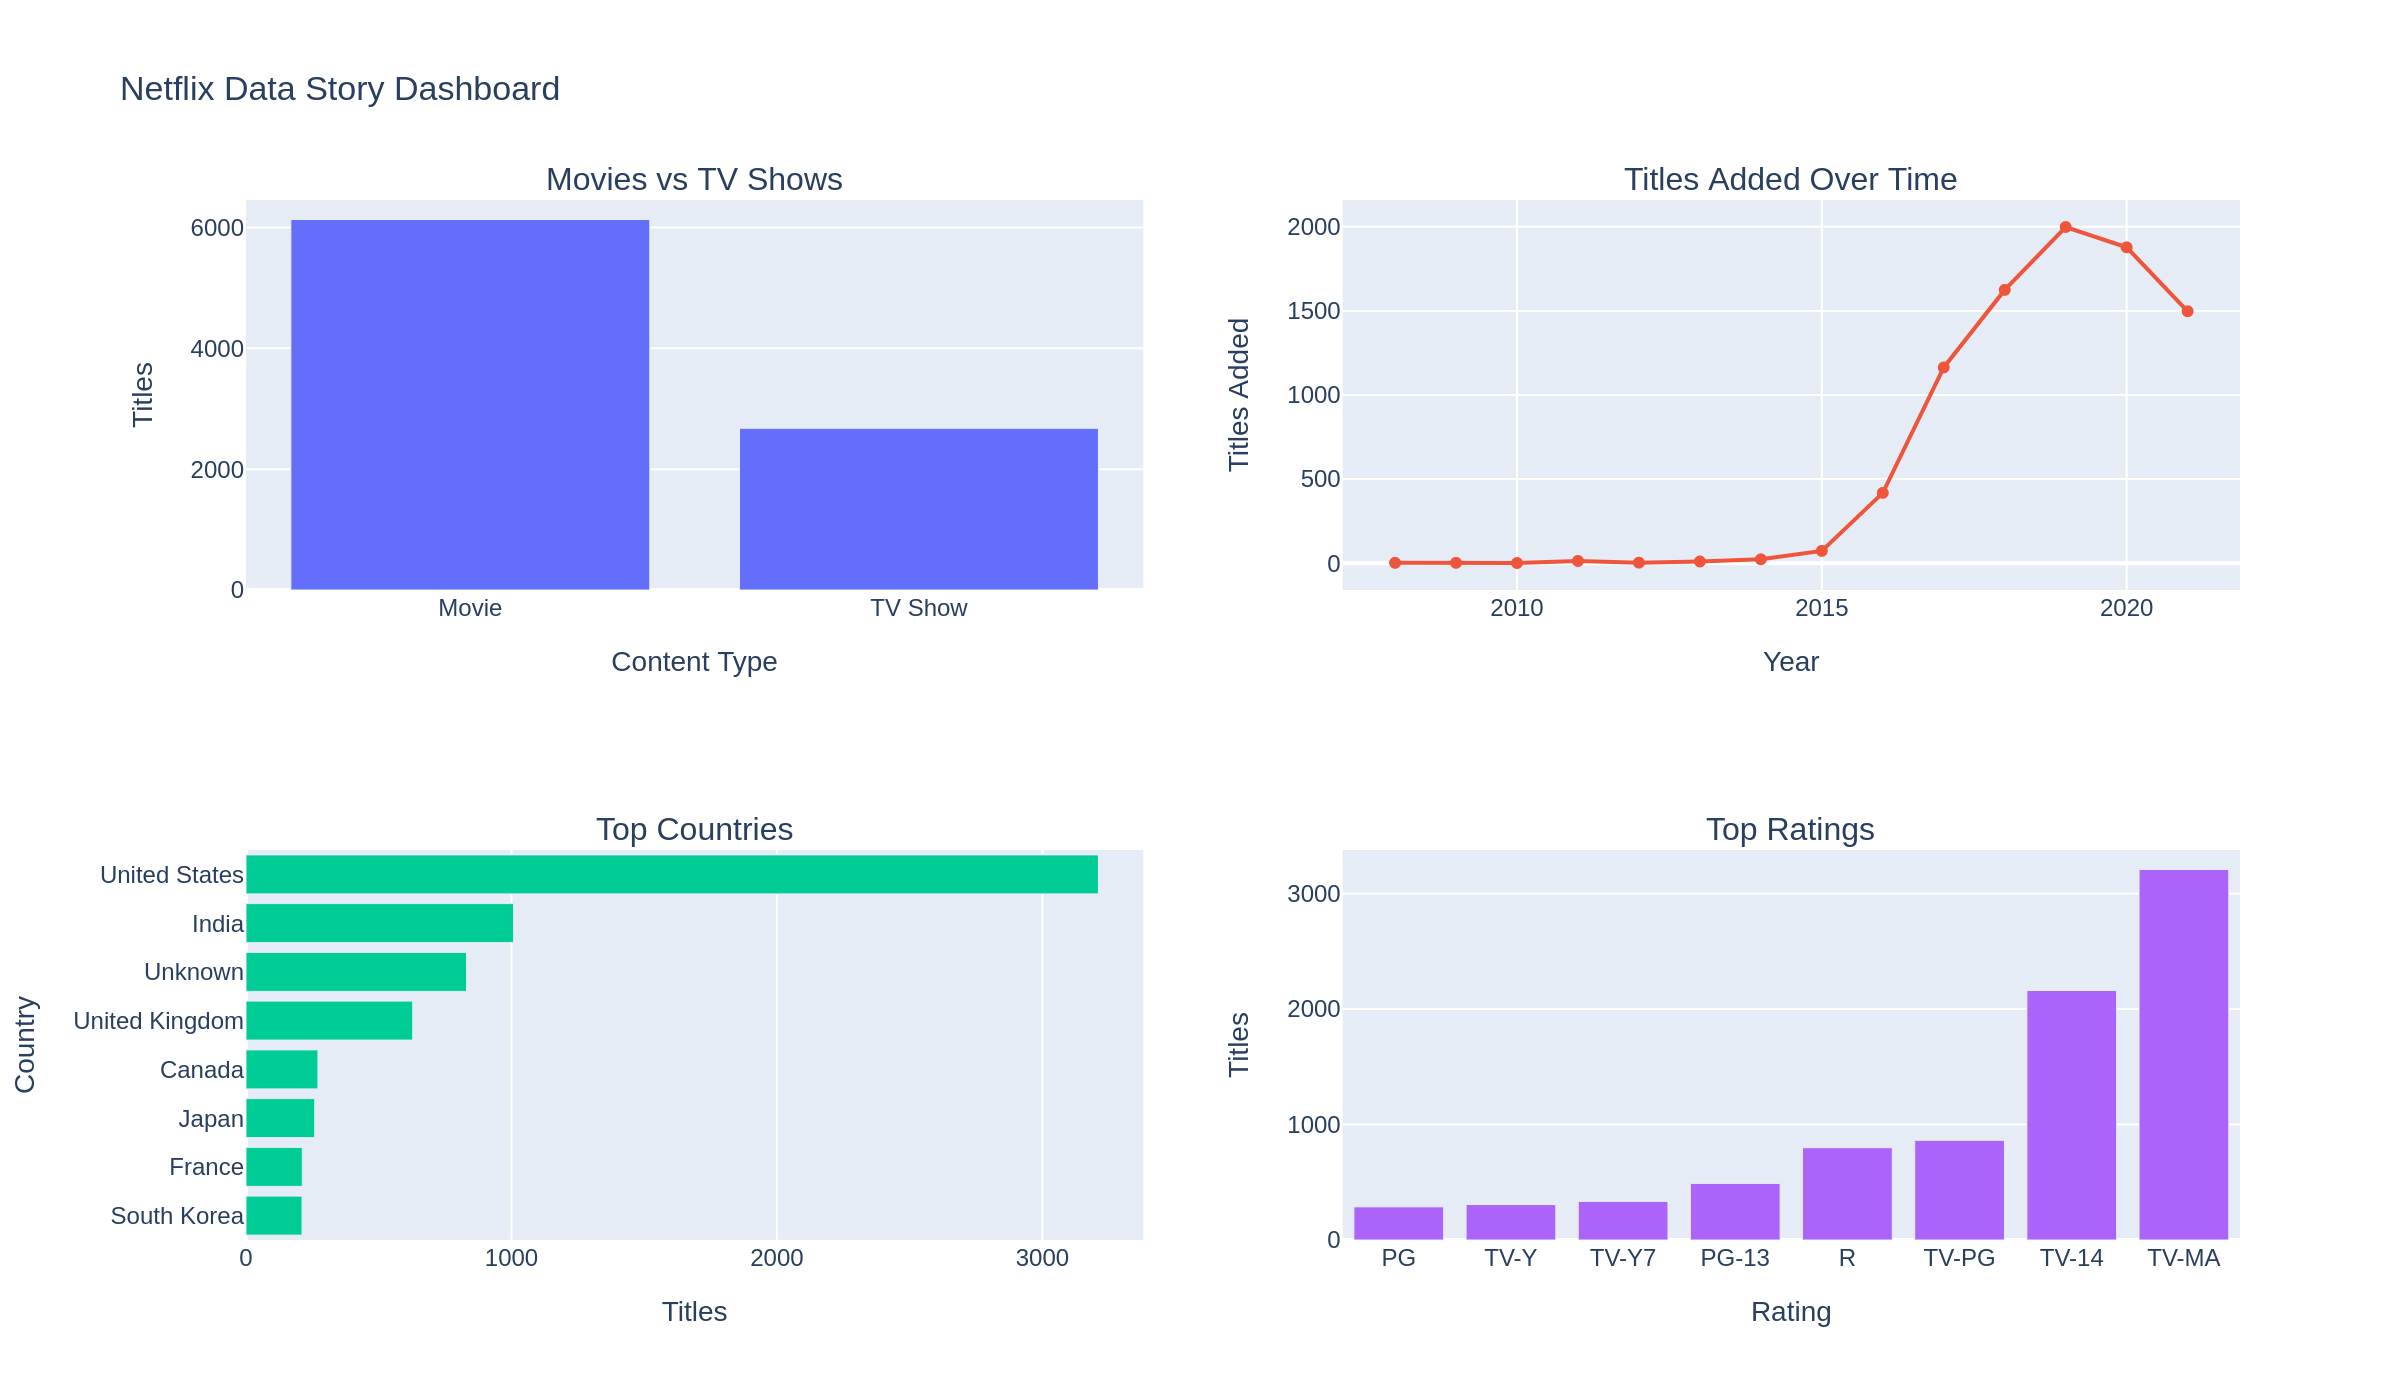

In [ ]:
# Prepare data for dashboard

# Content type
type_dashboard = (
    eda_df["type"]
    .value_counts()
    .reset_index()
)
type_dashboard.columns = ["type", "titles"]

# Yearly additions
year_dashboard = (
    eda_df["date_added_year"]
    .dropna()
    .astype(int)
    .value_counts()
    .sort_index()
    .reset_index()
)
year_dashboard.columns = ["year", "titles"]

# Top countries
country_dashboard = (
    eda_df["primary_country"]
    .value_counts()
    .head(8)
    .sort_values()
    .reset_index()
)
country_dashboard.columns = ["country", "titles"]

# Ratings
rating_dashboard = (
    eda_df["rating"]
    .value_counts()
    .head(8)
    .sort_values()
    .reset_index()
)
rating_dashboard.columns = ["rating", "titles"]


# Create dashboard
fig = make_subplots(
    rows=2,
    cols=2,
    subplot_titles=(
        "Movies vs TV Shows",
        "Titles Added Over Time",
        "Top Countries",
        "Top Ratings"
    )
)

# Chart 1
fig.add_trace(
    go.Bar(
        x=type_dashboard["type"],
        y=type_dashboard["titles"],
        name="Content Type"
    ),
    row=1,
    col=1
)

# Chart 2
fig.add_trace(
    go.Scatter(
        x=year_dashboard["year"],
        y=year_dashboard["titles"],
        mode="lines+markers",
        name="Titles Added"
    ),
    row=1,
    col=2
)

# Chart 3
fig.add_trace(
    go.Bar(
        x=country_dashboard["titles"],
        y=country_dashboard["country"],
        orientation="h",
        name="Countries"
    ),
    row=2,
    col=1
)

# Chart 4
fig.add_trace(
    go.Bar(
        x=rating_dashboard["rating"],
        y=rating_dashboard["titles"],
        name="Ratings"
    ),
    row=2,
    col=2
)

fig.update_layout(
    title_text="Netflix Data Story Dashboard",
    height=800,
    showlegend=False
)

fig.update_xaxes(title_text="Content Type", row=1, col=1)
fig.update_yaxes(title_text="Titles", row=1, col=1)

fig.update_xaxes(title_text="Year", row=1, col=2)
fig.update_yaxes(title_text="Titles Added", row=1, col=2)

fig.update_xaxes(title_text="Titles", row=2, col=1)
fig.update_yaxes(title_text="Country", row=2, col=1)

fig.update_xaxes(title_text="Rating", row=2, col=2)
fig.update_yaxes(title_text="Titles", row=2, col=2)

fig.show()
display(Image(fig.to_image(format="png", width=1200, height=700, scale=2)))

In [ ]:
# Most common content type
most_common_type = eda_df["type"].value_counts().idxmax()

# Most common country
most_common_country = eda_df["primary_country"].value_counts().idxmax()

# Most common rating
most_common_rating = eda_df["rating"].value_counts().idxmax()

# Most common genre
most_common_genre = eda_df["primary_genre"].value_counts().idxmax()

# Year with maximum additions
year_with_max_additions = (
    eda_df["date_added_year"]
    .dropna()
    .astype(int)
    .value_counts()
    .idxmax()
)

# Average movie duration
average_movie_duration = eda_df["duration_minutes"].mean()

print("KEY FINDINGS")
print("=" * 50)
print(f"Most common content type : {most_common_type}")
print(f"Top primary country      : {most_common_country}")
print(f"Most common rating       : {most_common_rating}")
print(f"Most common genre        : {most_common_genre}")
print(f"Peak year of additions   : {year_with_max_additions}")
print(f"Average movie duration   : {average_movie_duration:.1f} minutes")

KEY FINDINGS
Most common content type : Movie
Top primary country      : United States
Most common rating       : TV-MA
Most common genre        : Dramas
Peak year of additions   : 2019
Average movie duration   : 99.6 minutes


# Data Story

## 1. Business Context

Netflix operates a large content library containing both Movies and TV Shows.
Understanding the structure and evolution of this library is important for
content planning and strategic decision-making.

## 2. Key Metrics

The analysis begins with total titles, Movies, TV Shows, and the average release
year to establish the overall scale and composition of the dataset.

## 3. Content Trend

The yearly trend visualization shows how the Netflix content library has changed
over time and highlights periods of higher content additions.

## 4. Geographic Distribution

The country analysis shows which countries contribute the largest number of
titles to the dataset.

## 5. Audience and Content Profile

The rating and genre visualizations help identify the dominant categories of
content in the Netflix library.

## 6. Content Characteristics

Movie duration analysis shows the typical duration of movies and helps identify
unusually short or long titles.

## 7. Relationships and Patterns

The scatter plot and correlation heatmap help examine relationships between
numerical variables and identify patterns in the dataset.

## 8. Business Implications

The findings can help decision-makers understand content composition, geographic
concentration, audience categories, and changes in the content library over time.

# Actionable Recommendations

1. Monitor content additions over time to identify periods of strong or weak
   content growth and support future content planning.

2. Use country-level content patterns to understand geographic concentration
   and identify opportunities for broader regional representation.

3. Analyze dominant content ratings and genres when planning future acquisitions
   or productions.

4. Use movie-duration patterns to understand audience content preferences and
   maintain an appropriate mix of shorter and longer content.

5. Regularly update the analysis as new content is added so that business
   decisions remain aligned with current content trends.

# Final Business Dashboard

The dashboard combines the major KPIs and visualizations into a single
interactive view.

The dashboard helps stakeholders quickly understand:

- Overall content volume
- Movies versus TV Shows
- Content growth over time
- Geographic distribution
- Content-rating patterns
- Major trends and business opportunities

This presentation converts raw data into an easy-to-understand business story.

# Communication Note

Effective data storytelling improves communication by converting complex
analytical results into a clear sequence of evidence, insights, and actions.

Interactive visualizations allow business stakeholders to explore important
patterns quickly, while the accompanying narrative explains why those patterns
matter for business decisions.

A well-structured data story therefore helps stakeholders understand the
problem, interpret the findings, and connect analytical results with practical
business actions.

## Questions and Answers

### 1. What is data storytelling? How is it different from data visualization?

**Answer:**
Data storytelling is the process of combining data analysis, visualizations, and a narrative to communicate insights clearly and explain their meaning. Data visualization mainly presents information through charts and graphs, whereas data storytelling goes a step further by explaining the context, findings, significance, and possible actions based on the data.

---

### 2. Why is storytelling important in business analytics and decision-making?

**Answer:**
Storytelling is important because it converts complex analytical results into information that business stakeholders can easily understand. It helps explain important trends, problems, opportunities, and risks. By connecting data findings with a clear narrative, storytelling supports better understanding and more informed business decisions.

---

### 3. What are the essential components of an effective data story?

**Answer:**
The essential components of an effective data story are:

1. **Business problem or objective** – clearly defines what is being analyzed.
2. **Relevant data** – provides reliable information for the analysis.
3. **Visualizations** – present important patterns and trends clearly.
4. **Key insights** – explain what the visualizations reveal.
5. **Narrative** – connects the findings into a logical story.
6. **Recommendations** – suggest practical actions based on the findings.

---

### 4. How do Key Performance Indicators (KPIs) enhance business reporting?

**Answer:**
KPIs provide measurable values that summarize important aspects of business performance. They allow stakeholders to quickly understand the current situation and compare performance over time or across categories. For example, in the Netflix dataset, total titles, number of Movies, number of TV Shows, and average release year can serve as useful metrics for understanding the content library.

---

### 5. Why should visualizations be arranged in a logical sequence while presenting analytical findings?

**Answer:**
Visualizations should be arranged logically so that the audience can follow the analysis easily from the problem to the findings and recommendations. A logical sequence creates a clear data story. For example, a presentation can begin with KPIs, then show overall content trends, geographic distribution, ratings, relationships, key insights, and finally recommendations.

---

### 6. What factors should be considered while selecting visualizations for a business presentation?

**Answer:**
The visualization should be selected according to the type of data and the purpose of the analysis. Important factors include the number and type of variables, the relationship being studied, clarity, simplicity, audience understanding, and the business question being addressed.

For example, bar charts are suitable for comparing categories, line graphs for showing trends over time, scatter plots for relationships between numerical variables, and heatmaps for showing correlations.

---

### 7. Explain how dashboards and storytelling complement each other in Business Intelligence.

**Answer:**
Dashboards provide an interactive and visual summary of important business metrics, while storytelling explains the meaning and significance of the information shown in the dashboard. A dashboard helps stakeholders explore data quickly, whereas storytelling provides the context and narrative needed to understand the findings and connect them to business actions. Together, they make Business Intelligence more effective and easier to communicate.

---

### 8. What challenges may arise while communicating analytical insights to non-technical stakeholders?

**Answer:**
Non-technical stakeholders may find statistical terms, complex models, and detailed analytical results difficult to understand. Other challenges include information overload, unclear visualizations, lack of business context, and difficulty connecting technical findings with practical decisions.

These challenges can be reduced by using simple language, clear visualizations, relevant KPIs, and a logical narrative focused on business impact.

---

### 9. Give two real-world examples where data storytelling has influenced business or policy decisions.

**Answer:**

**Example 1 — Business:**
A retail company can analyze sales, customer behavior, and product performance through visualizations and present the findings as a data story. This can help management understand which products perform well and support decisions related to inventory and marketing.

**Example 2 — Public Policy:**
Government organizations can use data storytelling to present information about population trends, healthcare, employment, or economic conditions. Clear visualizations and explanations can help policymakers understand major issues and use the findings while planning public programs and policies.

---

### 10. How can effective data storytelling improve strategic planning and organizational performance?

**Answer:**
Effective data storytelling helps organizations understand important trends, identify opportunities and risks, and communicate findings clearly across teams. It connects analytical evidence with business objectives and practical actions. This supports better strategic planning, improves communication between analysts and stakeholders, and helps organizations make more informed decisions and improve overall performance.
